# 1. Imports and definiiton

In [1]:
# import the library
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import calendar
import numpy as np
import matplotlib.dates as mdates
import sys
import os
from os import listdir
from os.path import isfile, join
from dateutil import parser
import re
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (GradientBoostingRegressor, 
                              RandomForestRegressor, 
                              AdaBoostRegressor, 
                              BaggingRegressor, 
                              ExtraTreesRegressor,
                              HistGradientBoostingRegressor,
                              StackingRegressor,
                              VotingRegressor)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from datetime import datetime, timedelta
from matplotlib import animation
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.impute import SimpleImputer
# from func_defs import *

# %matplotlib ipympl
# %matplotlib inline


# define the inverter to analyse
inverter = '2-2'


# define the plot template
axis_label_size = 15
axis_num_size = 12
text_size = 12
title_size = 22

# define the figure size for single plot
figure_size = (6, 6)
subplot_size_1_2 = (6, 6)
long_hoz_figsize = (12, 6)

# 2. Electrical data visualisation

            Timestamp  1-1  1-2  10-1  10-2  11-1  11-2  12-1  12-2  13-1  \
0 2020-06-01 00:00:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
1 2020-06-01 00:05:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
2 2020-06-01 00:10:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
3 2020-06-01 00:15:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   
4 2020-06-01 00:20:00  0.0  0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

   ...  5-1  5-2  6-1  6-2  7-1  7-2  8-1  8-2  9-1  9-2  
0  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
2  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
3  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
4  ...  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 45 columns]


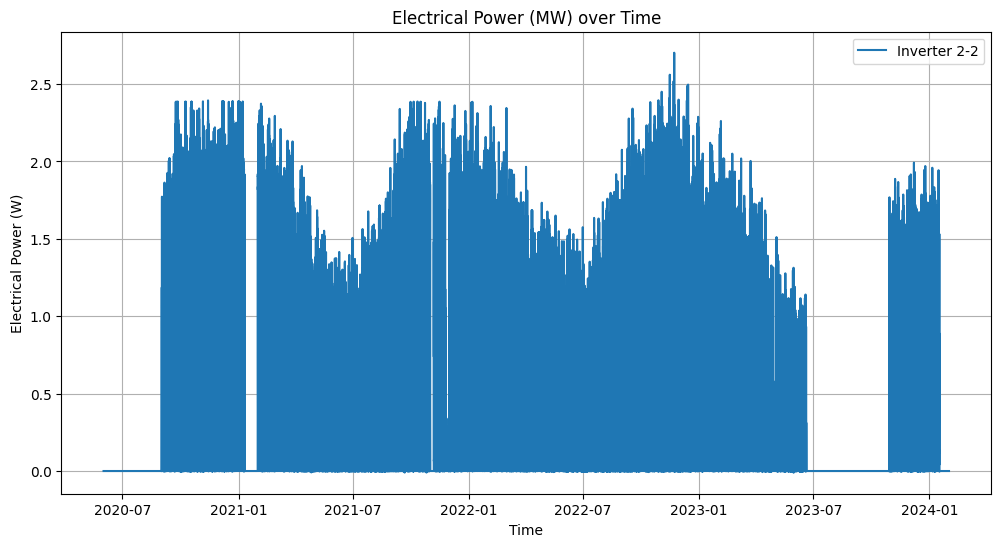

In [2]:
# Load the data from the pickle file
data_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\full_inv_pow_5min.pkl"
df = pd.read_pickle(data_file)

# print the head
print(df.head())

# Set the Timestamp as datatime format and index
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True)

# scale all values to MW from kW
df = df / 1000.0

# only keep the column for the selected inverter
df = df[[inverter]]

# plot the data, it only has one column
plt.figure(figsize=long_hoz_figsize)
plt.plot(df.index, df[inverter], label=f'Inverter {inverter}')
plt.legend()
plt.title('Electrical Power (MW) over Time')
plt.xlabel('Time')
plt.ylabel('Electrical Power (W)')
plt.grid()
plt.show()


# 3. Simulation results visualisation

## 3.1. Data loading

In [3]:
# Define CSV file path - user can modify this directly
simulation_results_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\PVsyst\per_inv\2-1\Bomen solar farm 2021 19 0.0 Perez model.csv"

print(f"Loading PVsyst CSV file: {simulation_results_file}")

try:
    # Load CSV with better parameters
    # Skip rows 0-9 (metadata), use row 10 as header, skip row 11 (units)
    simulation_results_df = pd.read_csv(
        simulation_results_file,
        delimiter=';',
        skiprows=list(range(10)) + [11],  # Skip metadata (0-9) and units row (11)
        header=0,  # Row 10 becomes the header after skipping
        encoding='latin-1',  # Keep the encoding that worked
        low_memory=False,
        na_values=['', ' ', 'nan', 'NaN']
    )
    
    print(f"Raw DataFrame loaded with shape: {simulation_results_df.shape}")
    
    # Get the first column (should be date/time)
    date_col = simulation_results_df.columns[0]
    print(f"Found date column: '{date_col}'")
    
    # Print sample of raw date values to debug
    print("Sample raw date values:")
    print(simulation_results_df[date_col].head(10).tolist())
    
    # Parse timestamps - Try multiple formats
    # First attempt the specified format
    simulation_results_df['timestamp'] = pd.to_datetime(
        simulation_results_df[date_col], 
        format='%d/%m/%Y %H:%M',  # Try full year format first
        errors='coerce'
    )
    
    # If we have NaT values, try alternative format with 2-digit year
    if simulation_results_df['timestamp'].isna().any():
        print("Some dates failed to parse. Trying alternative format...")
        simulation_results_df['timestamp'] = pd.to_datetime(
            simulation_results_df[date_col], 
            format='%d/%m/%y %H:%M',  # Try 2-digit year format
            errors='coerce'
        )
    
    # If still problems, try the flexible parser
    if simulation_results_df['timestamp'].isna().any():
        print("Still having parsing issues. Using flexible parser...")
        simulation_results_df['timestamp'] = pd.to_datetime(
            simulation_results_df[date_col],
            dayfirst=True,  # Important for DD/MM/YY format
            errors='coerce'
        )
    
    # Drop the original date column
    simulation_results_df = simulation_results_df.drop(columns=[date_col])
    
    # Basic data cleaning
    # Remove rows where timestamp is null
    initial_rows = len(simulation_results_df)
    simulation_results_df = simulation_results_df.dropna(subset=['timestamp'])
    print(f"Removed {initial_rows - len(simulation_results_df)} rows with invalid timestamps")
    
    # Sort by timestamp to ensure chronological order
    simulation_results_df = simulation_results_df.sort_values('timestamp').reset_index(drop=True)
    
    # Remove duplicate timestamps if any
    duplicates = simulation_results_df.duplicated(subset=['timestamp']).sum()
    if duplicates > 0:
        print(f"Found and removing {duplicates} duplicate timestamps")
        simulation_results_df = simulation_results_df.drop_duplicates(subset=['timestamp'], keep='first')
    
    # Data validation and timestamp analysis
    print("\n=== TIMESTAMP ANALYSIS ===")
    print(f"Total timestamps: {len(simulation_results_df)}")
    print(f"Date range: {simulation_results_df['timestamp'].min()} to {simulation_results_df['timestamp'].max()}")
    
    # Check timestamp continuity
    time_diffs = simulation_results_df['timestamp'].diff()[1:]  # Skip first NaT
    common_diff = time_diffs.value_counts().index[0]
    print(f"Most common time difference: {common_diff}")
    
    irregular_intervals = (time_diffs != common_diff).sum()
    if irregular_intervals > 0:
        print(f"Warning: Found {irregular_intervals} irregular time intervals")
    
    # Check distribution of timestamps by month
    month_counts = simulation_results_df['timestamp'].dt.month.value_counts().sort_index()
    print("\nTimestamps per month:")
    for month, count in month_counts.items():
        print(f"Month {month}: {count} timestamps")
    
    # Check the first and last few days of each month
    print("\nDate ranges by month:")
    for month in sorted(simulation_results_df['timestamp'].dt.month.unique()):
        month_data = simulation_results_df[simulation_results_df['timestamp'].dt.month == month]
        print(f"Month {month}: {month_data['timestamp'].min()} to {month_data['timestamp'].max()}")
        # Get unique days in this month
        days = sorted(month_data['timestamp'].dt.day.unique())
        print(f"  Days: {days[:5]}...{days[-5:] if len(days) > 5 else days}")
    
    # Print the columns
    print("\nColumns:")
    print(simulation_results_df.columns.tolist())
    
    # Check for 'EArray' column
    print(f"Does 'EArray' column exist? {'EArray' in simulation_results_df.columns}")
    
except Exception as e:
    print(f"Error loading PVsyst CSV: {e}")
    raise

Loading PVsyst CSV file: C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Data\PVsyst\per_inv\2-1\Bomen solar farm 2021 19 0.0 Perez model.csv
Raw DataFrame loaded with shape: (8736, 148)
Found date column: 'date'
Sample raw date values:
['01/01/21 00:00', '01/01/21 01:00', '01/01/21 02:00', '01/01/21 03:00', '01/01/21 04:00', '01/01/21 05:00', '01/01/21 06:00', '01/01/21 07:00', '01/01/21 08:00', '01/01/21 09:00']
Some dates failed to parse. Trying alternative format...
Removed 0 rows with invalid timestamps

=== TIMESTAMP ANALYSIS ===
Total timestamps: 8736
Date range: 2021-01-01 00:00:00 to 2021-12-30 23:00:00
Most common time difference: 0 days 01:00:00

Timestamps per month:
Month 1: 744 timestamps
Month 2: 672 timestamps
Month 3: 744 timestamps
Month 4: 720 timestamps
Month 5: 744 timestamps
Month 6: 720 timestamps
Month 7: 744 timestamps
Month 8: 744 timestamps
Month 9: 720 timestamps
Month 10: 744 timestamps
Month 11: 720 timestamps
Month 12:

## 3.2. Visualisation

### 3.2.1. Hourly raw data

EArray column is already numeric type: float64
Set timestamp as index
No clipping applied to EArray values
Resampled actual power from 385920 5-minute intervals to 32160 hourly averages


C:\Users\z5183876\AppData\Local\Temp\ipykernel_34244\418022559.py:34: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_actual_power = df[inverter].resample('H').mean()


EArray Min: 0.00 MW
EArray Max: 2.40 MW
EArray Mean: 0.47 MW
Total simulation data points: 8736

Actual Power Min: -0.00 MW
Actual Power Max: 2.09 MW
Actual Power Mean: 0.35 MW
Total actual data points: 32160


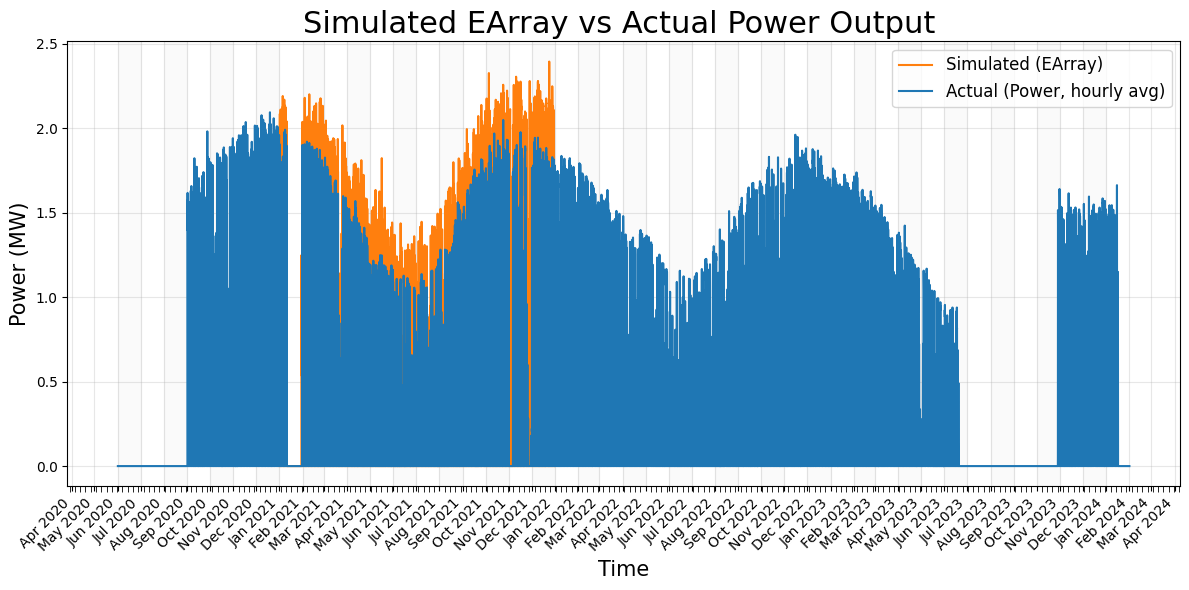

In [4]:
# %matplotlib ipympl
# Define clipping options at the beginning
apply_clipping = False  # Set to False to disable clipping
clipping_threshold = 100  # Clipping threshold in MW

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['EArray']):
    # Only convert if it's still a string/object type
    simulation_results_df['EArray'] = pd.to_numeric(
        simulation_results_df['EArray'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['EArray'].dtype)

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Apply clipping to the simulated power if enabled
if apply_clipping:
    simulation_results_df['EArray_display'] = simulation_results_df['EArray'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to EArray values: {(simulation_results_df['EArray'] > clipping_threshold).sum()} values clipped")
    earray_label = f'Simulated (EArray, clipped at {clipping_threshold} MW)'
else:
    simulation_results_df['EArray_display'] = simulation_results_df['EArray']
    print("No clipping applied to EArray values")
    earray_label = 'Simulated (EArray)'

# Resample the actual power data to hourly averages
hourly_actual_power = df[inverter].resample('H').mean()
# hourly_actual_power = df[inverter].resample('H').first()
print(f"Resampled actual power from {len(df)} 5-minute intervals to {len(hourly_actual_power)} hourly averages")

# Create a figure for both datasets
fig = plt.figure(figsize=long_hoz_figsize)
ax = fig.add_subplot(111)

# Plot simulation EArray data (with or without clipping)
ax.plot(simulation_results_df.index, simulation_results_df['EArray_display'], 
       linewidth=1.5, color='#ff7f0e', label=earray_label)

# Plot actual power data (hourly resampled)
ax.plot(hourly_actual_power.index, hourly_actual_power, 
       linewidth=1.5, color='#1f77b4', label='Actual (Power, hourly avg)')

# Add labels and title
ax.set_xlabel('Time', fontsize=axis_label_size)
ax.set_ylabel('Power (MW)', fontsize=axis_label_size)
title_suffix = " (clipped)" if apply_clipping else ""
ax.set_title(f'Simulated EArray vs Actual Power Output {title_suffix}', fontsize=title_size)

# Add legend
ax.legend(fontsize=text_size)

# Add grid
ax.grid(True, alpha=0.3)

# Enhanced date formatting on x-axis
# Use major ticks for months
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Add minor ticks for days (every 7 days)
ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
ax.tick_params(which='minor', length=4, color='k')

# Make sure all dates are visible
fig.autofmt_xdate(rotation=45)

# Increase bottom margin to accommodate date labels
plt.subplots_adjust(bottom=0.2)

# Add a colorized background to differentiate months
first_date = min(simulation_results_df.index.min(), hourly_actual_power.index.min())
last_date = max(simulation_results_df.index.max(), hourly_actual_power.index.max())
months = pd.date_range(start=first_date, end=last_date, freq='MS')


for i, month_start in enumerate(months):
    # Get the last day of the month
    if i < len(months) - 1:
        month_end = months[i + 1]
    else:
        # For the last month, use the last date in our data
        month_end = last_date
    
    # Add a subtle background color alternating between months
    if i % 2 == 0:
        ax.axvspan(month_start, month_end, alpha=0.1, color='lightgray')

# Adjust layout
plt.tight_layout()

# Print some statistics
print(f"EArray Min: {simulation_results_df['EArray_display'].min():.2f} MW")
print(f"EArray Max: {simulation_results_df['EArray_display'].max():.2f} MW")
print(f"EArray Mean: {simulation_results_df['EArray_display'].mean():.2f} MW")
print(f"Total simulation data points: {len(simulation_results_df)}")

print(f"\nActual Power Min: {hourly_actual_power.min():.2f} MW")
print(f"Actual Power Max: {hourly_actual_power.max():.2f} MW")
print(f"Actual Power Mean: {hourly_actual_power.mean():.2f} MW")
print(f"Total actual data points: {len(hourly_actual_power)}")

# Show plot
plt.show()

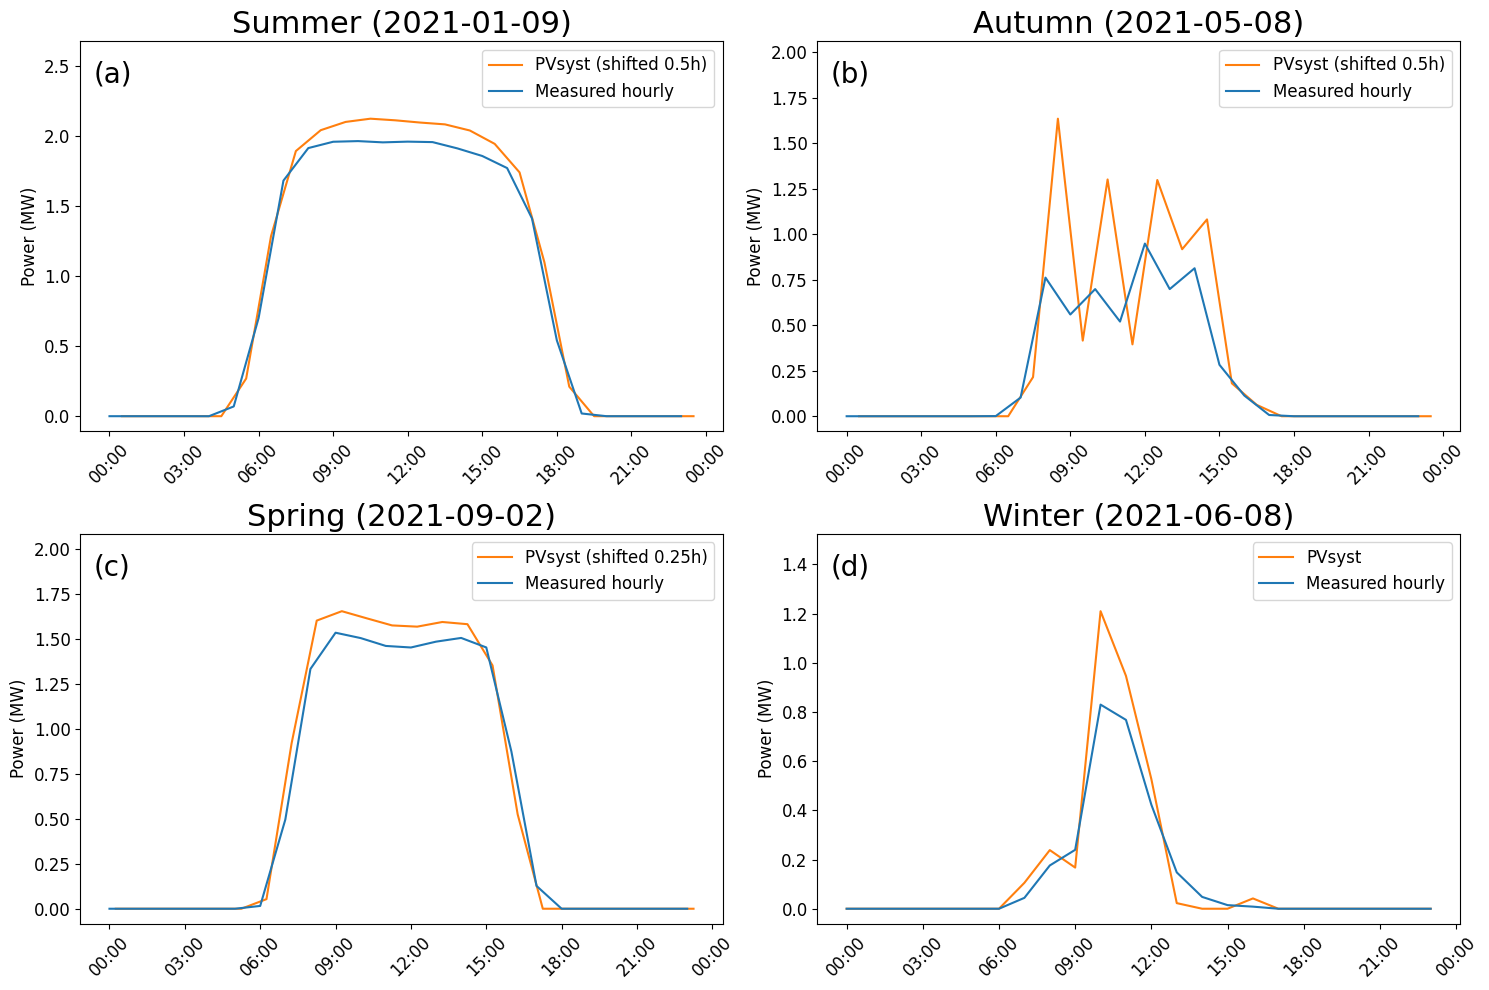

In [5]:
def plot_four_days(dates, time_shifts=None):
    """
    Create a 2x2 subplot grid showing actual vs simulated power for 4 specific days
    
    Parameters:
    -----------
    dates : list
        List of 4 dates as strings in format 'YYYY-MM-DD'
    time_shifts : list, optional
        List of time shifts in hours to apply to each simulated day. 
        Positive values shift data forward in time (later), negative values shift backward (earlier).
        Default is None (no shifts).
    """
    # Convert date strings to datetime objects
    dates = [pd.to_datetime(date) for date in dates]
    
    # If no time shifts provided, default to no shift (0) for each date
    if time_shifts is None:
        time_shifts = [0, 0, 0, 0]
    
    # Create 2x2 subplot grid
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()  # Flatten to make indexing easier
    labels = ['a', 'b', 'c', 'd']  # Labels for subplots
    
    # Function to get season in Australia
    def get_season(date):
        """Returns the season in Australia based on the date."""
        month = date.month
        day = date.day
        if (month == 12 and day >= 1) or month in [1, 2] or (month == 3 and day < 1):
            return "Summer"
        elif month in [3, 4, 5]:
            return "Autumn"
        elif month in [6, 7, 8]:
            return "Winter"
        else:  # month in [9, 10, 11]
            return "Spring"
    
    # Suppress FutureWarning about 'H' vs 'h'
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # Loop through each date and create a subplot
    for i, (date, time_shift) in enumerate(zip(dates, time_shifts)):
        # Get just the data for this specific day
        day_start = date.replace(hour=0, minute=0, second=0)
        day_end = date.replace(hour=23, minute=59, second=59)
        
        # Filter actual data (resample to hourly for fair comparison)
        actual_day = df[inverter].loc[day_start:day_end].resample('h').mean()
        
        # Get simulation data directly
        sim_day = simulation_results_df['EArray'].loc[day_start:day_end]
        
        # Apply time shift to simulation data if specified
        if time_shift != 0:
            # Create a copy with shifted index
            sim_day_shifted = sim_day.copy()
            sim_day_shifted.index = sim_day.index + pd.Timedelta(hours=time_shift)
            
            # Filter to keep only data points within the same day
            sim_day = sim_day_shifted[
                (sim_day_shifted.index >= day_start) & 
                (sim_day_shifted.index <= day_end)
            ]
        
        # Select the current axis for plotting
        ax = axs[i]
        
        # Plot simulation data
        ax.plot(sim_day.index, sim_day.values, linewidth=1.5, color='#ff7f0e', 
                label=f'PVsyst{" (shifted " + str(time_shift) + "h)" if time_shift != 0 else ""}')
        
        # Plot actual power data
        ax.plot(actual_day.index, actual_day.values, linewidth=1.5, color='#1f77b4', label='Measured hourly')
        
        # Get season for the date
        season = get_season(date)
        
        # Set title and labels with date included
        title_text = f"{season} ({date.strftime('%Y-%m-%d')})"
        ax.set_title(title_text, fontsize=title_size)
        
        ax.set_ylabel('Power (MW)', fontsize=text_size)
        
        # Add subplot label
        ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=20, verticalalignment='top')
        
        # Format x-axis to show hours:minutes with date
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', rotation=45, labelsize=text_size)
        ax.tick_params(axis='y', labelsize=text_size)
        
        # Add legend in upper right
        ax.legend(loc='upper right', fontsize=text_size)
        
        # Increase y-limit to add more space at the top for the legend
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] * 1.2)
    
    plt.tight_layout()
    plt.show()
    
    return fig, axs

# Example usage with time shifts
dates_to_plot = [
    '2021-01-09',  # Spring
    '2021-05-08',  # Summer
    '2021-09-02',  # Autumn
    '2021-06-08'   # Winter
]

# Define time shifts in hours for each day (can be integer or float)
time_shifts = [0.5, 0.5, 0.25, 0]  # Positive shifts data later, negative shifts earlier

# Call the function with time shifts
fig, axes = plot_four_days(dates_to_plot, time_shifts)

### 3.2.2. Hourly filtered & scaled

EArray column is already numeric type: float64
Applied 2.392 MW clipping to power values: 1 values clipped
Maximum power reduced from 2.40 MW to 2.39 MW
Selected first value of each hour from 385920 5-minute intervals to get 32160 hourly points
Working with hourly data - 32160 actual data points and 8736 simulation data points

=== DATA FILTERING FOR METRICS CALCULATION ===
Step 1: Creating filtered dataframe for metrics
After filtering for matching timestamps: 8736 data points (removed 23424 NaN values)
Zero filtering step removed - keeping all data points including zeros

Step 2: Loading and applying maintenance-free days filter
Loaded 233 maintenance-free days
After filtering for maintenance-free days: 5592 data points (removed 3144 points)

Filtered data date range: 2021-01-01 00:00:00 to 2021-12-30 23:00:00
Number of unique days in filtered data: 233

=== SCALING FACTOR OPTIMIZATION ===
Target MBE tolerance: 1.00e-13

Starting binary search for optimal scaling factor...
Initial se

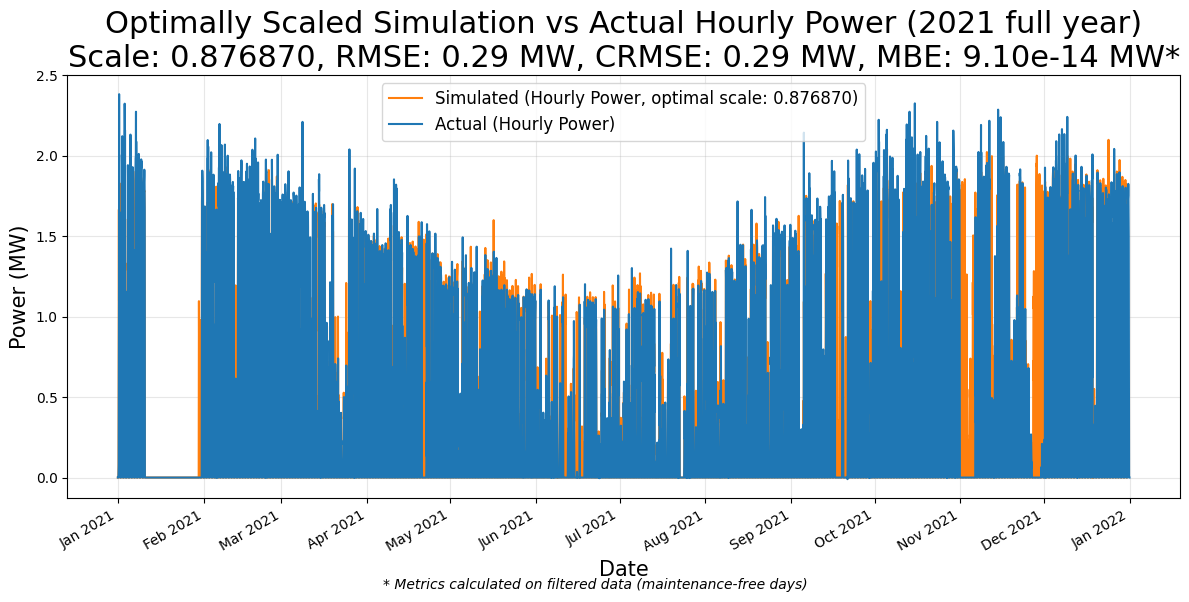


=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===
2021 simulation data points: 8736
2021 actual data points: 8760
Scaled Power Min: 0.00 MW
Scaled Power Max: 2.10 MW
Scaled Power Mean: 0.42 MW
Actual Power Min: -0.01 MW
Actual Power Max: 2.38 MW
Actual Power Mean: 0.40 MW

=== FILTERED 2021 DATA FOR PLOTTING ===
Total days in filtered 2021 data: 5592
Mean difference: 9.099889813226612e-14
Median difference: 0.0
The difference is PVsyst - Measured


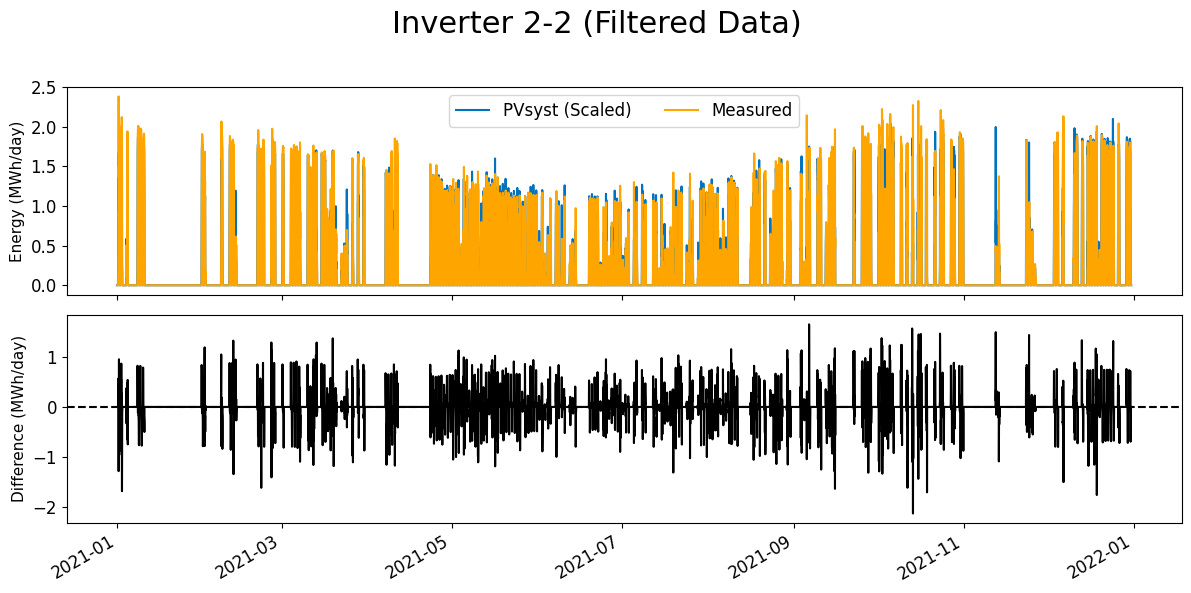


Evaluation Metrics for Inverter 2-2 (FILTERED DATA):
Optimal scaling factor: 0.876870
MBE   : 0.000 MWh/day
MAE   : 0.130 MWh/day
RMSE  : 0.285 MWh/day
CRMSE : 0.285 MWh/day
CMAE  : 0.130 MWh/day
nRMSE : 11.963% (range)
NMAE  : 5.448% (range)
MAPE  : inf%


In [6]:
# Define options at the beginning
apply_clipping = True  # Set to False to disable clipping
clipping_threshold = 2.392 # MW - power clipping threshold 
target_mbe_tolerance = 1e-13  # Target absolute MBE to achieve

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['EArray']):
    # Only convert if it's still a string/object type
    simulation_results_df['EArray'] = pd.to_numeric(
        simulation_results_df['EArray'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['EArray'].dtype)

# Apply clipping to raw power values
if apply_clipping:
    original_max = simulation_results_df['EArray'].max()
    clipped_count = (simulation_results_df['EArray'] > clipping_threshold).sum()
    simulation_results_df['EArray'] = simulation_results_df['EArray'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to power values: {clipped_count} values clipped")
    print(f"Maximum power reduced from {original_max:.2f} MW to {simulation_results_df['EArray'].max():.2f} MW")

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Resample the actual power data to hourly averages to match simulation data frequency
hourly_actual_power = df[inverter].resample('H').first()  # Using first value instead of mean
print(f"Selected first value of each hour from {len(df)} 5-minute intervals to get {len(hourly_actual_power)} hourly points")

# No resampling to daily - keeping hourly resolution
print(f"Working with hourly data - {len(hourly_actual_power)} actual data points and {len(simulation_results_df)} simulation data points")

# Create a combined dataframe with both actual and simulated power for metrics calculation
print("\n=== DATA FILTERING FOR METRICS CALCULATION ===")
print("Step 1: Creating filtered dataframe for metrics")
metrics_df = pd.DataFrame()
metrics_df['Actual'] = hourly_actual_power
metrics_df['Simulated'] = simulation_results_df['EArray']

# Filter to include only timestamps where both actual and simulated power exist
initial_rows = len(metrics_df)
metrics_df = metrics_df.dropna()
print(f"After filtering for matching timestamps: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} NaN values)")

# Keeping all values including zeros
print("Zero filtering step removed - keeping all data points including zeros")

# Load the maintenance-free days from the text file
print("\nStep 2: Loading and applying maintenance-free days filter")
maintenance_free_days_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\remaining_dates_2021.txt"
try:
    with open(maintenance_free_days_file, 'r') as f:
        maintenance_free_days = [line.strip() for line in f.readlines() if line.strip()]
    
    print(f"Loaded {len(maintenance_free_days)} maintenance-free days")
    
    # Convert maintenance-free days to datetime for filtering
    maintenance_free_dates = pd.to_datetime(maintenance_free_days)
    
    # Filter the metrics dataframe to only include maintenance-free days
    metrics_df['date'] = metrics_df.index.date
    initial_rows = len(metrics_df)
    metrics_df = metrics_df[metrics_df['date'].isin([date.date() for date in maintenance_free_dates])]
    
    print(f"After filtering for maintenance-free days: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} points)")
    
except Exception as e:
    print(f"Error loading maintenance-free days: {e}")
    print("Continuing with only the non-NaN data points")

# Print the date range of the filtered data
if len(metrics_df) > 0:
    print(f"\nFiltered data date range: {metrics_df.index.min()} to {metrics_df.index.max()}")
    print(f"Number of unique days in filtered data: {len(metrics_df['date'].unique())}")
else:
    print("\nWarning: No data points remain after filtering!")
    print("Please check your maintenance-free days file and data availability.")

# Check if we have enough data to proceed
if len(metrics_df) < 10:
    print("\nWARNING: Very few data points remain after filtering!")
    print("Results may not be statistically significant.")

# Function to calculate MBE for a given scale factor (uses filtered data)
def calculate_mbe(scale_factor, apply_clip=False, clip_threshold=2.392):
    """Calculate Mean Bias Error for given scale factor"""
    # Scale the simulated data (clipping already applied at power level)
    scaled_data = metrics_df['Simulated'] * scale_factor
    
    # Calculate MBE
    return np.mean(scaled_data - metrics_df['Actual'])

print("\n=== SCALING FACTOR OPTIMIZATION ===")
print(f"Target MBE tolerance: {target_mbe_tolerance:.2e}")

# Binary search to find optimal scaling factor
def find_optimal_scaling_factor(min_factor=0.5, max_factor=2.0, max_iterations=100):
    print("\nStarting binary search for optimal scaling factor...")
    print(f"Initial search range: [{min_factor:.8f}, {max_factor:.8f}]")
    
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        
        # Calculate MBE for the current factor
        mbe = calculate_mbe(mid_factor, apply_clipping, clipping_threshold)
        
        # Track the best factor found
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
        
        # Check if we've reached the target precision
        if abs(mbe) < target_mbe_tolerance:
            print(f"✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations
        
        # Adjust search range based on MBE sign
        if mbe > 0:  # MBE is positive, need to decrease factor
            max_factor = mid_factor
        else:  # MBE is negative, need to increase factor
            min_factor = mid_factor
        
        # Check if search range is too small (reached numerical precision limit)
        if max_factor - min_factor < 1e-15:
            print(f"! Reached numerical precision limit after {iterations} iterations.")
            print(f"  Best MBE achieved: {best_mbe:.12e}")
            return best_factor, best_mbe, iterations
    
    print(f"! Reached maximum iterations ({max_iterations}).")
    print(f"  Best MBE achieved: {best_mbe:.12e}")
    return best_factor, best_mbe, iterations

# Only proceed with optimization if we have data
if len(metrics_df) > 0:
    # Find the optimal scaling factor using filtered data
    optimal_factor, final_mbe, iterations = find_optimal_scaling_factor()

    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Optimal scaling factor: {optimal_factor:.10f}")
    print(f"Final MBE: {final_mbe:.12e} MW")  # Changed from MWh/day to MW
    print(f"Found in {iterations} iterations")

    # Apply the optimal scaling factor to the filtered data for metrics
    PVsyst_scaling = optimal_factor
    print(f"\nApplying optimal scale factor {PVsyst_scaling:.10f} to PVsyst data...")

    # Apply scale factor to filtered data (clipping already applied at power level)
    metrics_df['Simulated_scaled'] = metrics_df['Simulated'] * PVsyst_scaling
    
    # No need to apply clipping again since it was done at the power level
    metrics_df['Simulated_display'] = metrics_df['Simulated_scaled']

    # Calculate error metrics with optimal scaling (using filtered data)
    # 1. RMSE (Root Mean Square Error)
    rmse = np.sqrt(mean_squared_error(metrics_df['Actual'], metrics_df['Simulated_display']))
    
    # 2. CRMSE (Centralized Root Mean Square Error)
    actual_centered = metrics_df['Actual'] - metrics_df['Actual'].mean()
    simulated_centered = metrics_df['Simulated_display'] - metrics_df['Simulated_display'].mean()
    crmse = np.sqrt(np.mean((actual_centered - simulated_centered)**2))
    
    # 3. MBE (Mean Bias Error) - should be very close to zero
    mbe = np.mean(metrics_df['Simulated_display'] - metrics_df['Actual'])
    
    print("\n=== ERROR METRICS WITH OPTIMAL SCALING (ON FILTERED DATA) ===")
    print(f"RMSE: {rmse:.4f} MW")  # Changed from MWh/day to MW
    print(f"CRMSE: {crmse:.4f} MW")  # Changed from MWh/day to MW
    print(f"MBE: {mbe:.12e} MW")  # Changed from MWh/day to MW
    # calculate the normalised RMSE as a percentage of the range of actual values
    nrmse = rmse / (metrics_df['Actual'].max() - metrics_df['Actual'].min())
    print(f"nRMSE: {nrmse:.4%} of actual range")
    
    # Verify if target was met
    if abs(mbe) < target_mbe_tolerance:
        print(f"✓ SUCCESS: |MBE| = {abs(mbe):.12e} < {target_mbe_tolerance:.2e}")
    else:
        print(f"! WARNING: |MBE| = {abs(mbe):.12e} > {target_mbe_tolerance:.2e}")
        print("  Target tolerance not achieved exactly due to numerical precision limits.")

    # Create a figure showing optimized results for 2021 data only
    plt.figure(figsize=long_hoz_figsize)
    
    # Apply the same scaling factor to all simulation data for plotting
    all_simulation_scaled = simulation_results_df['EArray'] * PVsyst_scaling
    
    # Filter for 2021 data only
    year_2021_simulated = all_simulation_scaled[all_simulation_scaled.index.year == 2021]
    year_2021_actual = hourly_actual_power[hourly_actual_power.index.year == 2021]
    
    print(f"\n=== 2021 DATA FILTERING ===")
    print(f"Total hours in 2021 with simulation data: {len(year_2021_simulated)}")
    print(f"Total hours in 2021 with actual data: {len(year_2021_actual)}")

    # Plot 2021 scaled simulation data
    plt.plot(year_2021_simulated.index, year_2021_simulated, 
             linewidth=1.5, color='#ff7f0e', label=f'Simulated (Hourly Power, optimal scale: {PVsyst_scaling:.6f})')

    # Plot 2021 actual power data
    plt.plot(year_2021_actual.index, year_2021_actual, 
             linewidth=1.5, color='#1f77b4', label='Actual (Hourly Power)')

    # Add labels and title
    plt.xlabel('Date', fontsize=axis_label_size)
    plt.ylabel('Power (MW)', fontsize=axis_label_size)  # Changed from Energy to Power

    # Add metrics to title (but note these are from filtered data)
    plt.title(f'Optimally Scaled Simulation vs Actual Hourly Power (2021 full year)\n'
              f'Scale: {optimal_factor:.6f}, RMSE: {rmse:.2f} MW, CRMSE: {crmse:.2f} MW, MBE: {mbe:.2e} MW*', 
              fontsize=title_size)
    
    # Add a note about metrics
    plt.figtext(0.5, 0.01, 
                '* Metrics calculated on filtered data (maintenance-free days)',
                ha='center', fontsize=10, style='italic')

    # Add legend and formatting
    plt.legend(fontsize=text_size)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    # Show plot
    plt.show()

    # Print statistics for 2021 data
    print(f"\n=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===")
    print(f"2021 simulation data points: {len(year_2021_simulated)}")
    print(f"2021 actual data points: {len(year_2021_actual)}")
    print(f"Scaled Power Min: {year_2021_simulated.min():.2f} MW")
    print(f"Scaled Power Max: {year_2021_simulated.max():.2f} MW")
    print(f"Scaled Power Mean: {year_2021_simulated.mean():.2f} MW")
    print(f"Actual Power Min: {year_2021_actual.min():.2f} MW")
    print(f"Actual Power Max: {year_2021_actual.max():.2f} MW")
    print(f"Actual Power Mean: {year_2021_actual.mean():.2f} MW")
else:
    print("\nERROR: No data points remain after filtering. Cannot proceed with optimization.")
    print("Please check your maintenance-free days file and data availability.")


# Create a two-panel figure showing FILTERED 2021 data (instead of all data)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                              gridspec_kw={'height_ratios':[1,1]})

# Add a proper title at the top of the figure with inverter information
fig.suptitle(f'Inverter {inverter} (Filtered Data)', 
             fontsize=title_size, y=0.98)

# Make sure we're using the properly filtered data
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()
print(f"\n=== FILTERED 2021 DATA FOR PLOTTING ===")
print(f"Total days in filtered 2021 data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Plot the simulated data (filtered, scaled)
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated_display'], 
             label='PVsyst (Scaled)', color='#0072BF')
    
    # Plot the filtered actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals (Simulated - Actual)
    residuals = filtered_2021_metrics['Simulated_display'] - filtered_2021_metrics['Actual']
    print("Mean difference:", residuals.mean())
    print("Median difference:", residuals.median())
    print('The difference is PVsyst - Measured')
    
    # Plot residuals in bottom panel
    ax2.plot(residuals.index, residuals, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add x-axis formatting
    plt.gcf().autofmt_xdate()
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate the suptitle
    
    # Show plot
    plt.show()
    
    # Calculate metrics on filtered data
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    cmae = np.mean(np.abs(residuals - mbe))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse = rmse / meas_range * 100
    nmae = mae / meas_range * 100
    mape = np.mean(np.abs(residuals / filtered_2021_metrics['Actual'])) * 100
    
    # Print metrics for filtered data
    print(f"\nEvaluation Metrics for Inverter {inverter} (FILTERED DATA):")
    print(f"Optimal scaling factor: {optimal_factor:.6f}")
    print(f"MBE   : {mbe:.3f} MWh/day")
    print(f"MAE   : {mae:.3f} MWh/day")
    print(f"RMSE  : {rmse:.3f} MWh/day")
    print(f"CRMSE : {crmse:.3f} MWh/day")
    print(f"CMAE  : {cmae:.3f} MWh/day")
    print(f"nRMSE : {nrmse:.3f}% (range)")
    print(f"NMAE  : {nmae:.3f}% (range)")
    print(f"MAPE  : {mape:.3f}%")
    
    # Save the filtered comparison plot
    # plot_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_vs_measured_comparison_filtered.png"
    # fig.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    # print(f"\nFiltered plot saved to: {plot_file_path}")
    
else:
    print("\nERROR: No filtered data points from 2021 remain after filtering.")
    print("Please check your maintenance-free days file and data availability.")

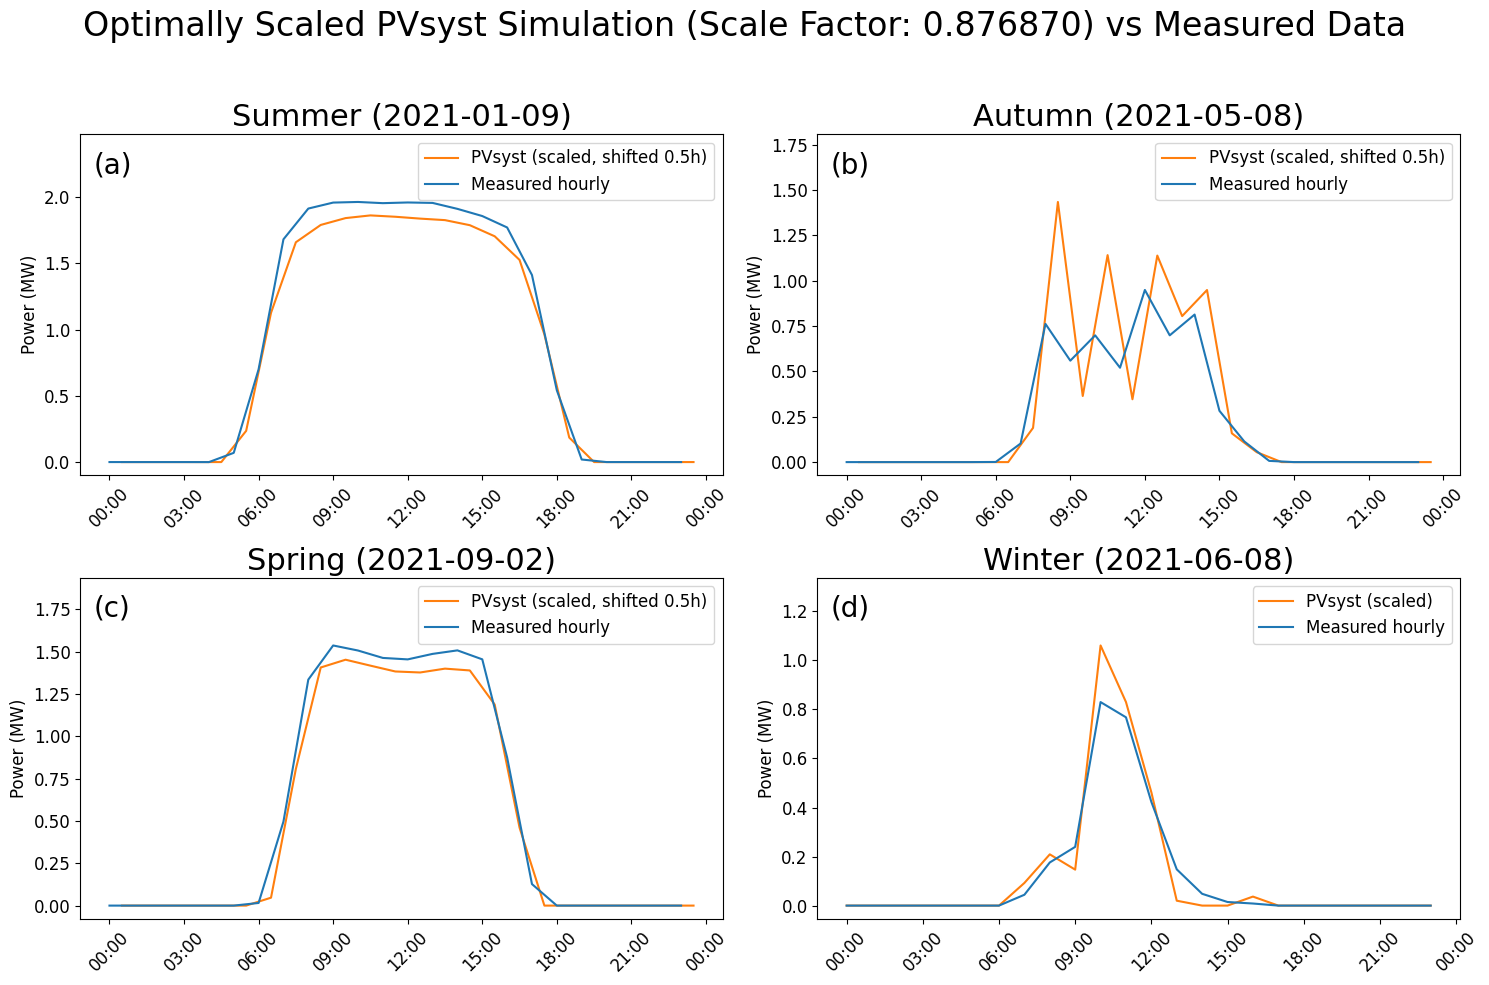

In [7]:
def plot_four_days_scaled(dates, time_shifts=None):
    """
    Create a 2x2 subplot grid showing actual vs optimally scaled simulated power for 4 specific days
    
    Parameters:
    -----------
    dates : list
        List of 4 dates as strings in format 'YYYY-MM-DD'
    time_shifts : list, optional
        List of time shifts in hours to apply to each simulated day. 
        Positive values shift data forward in time (later), negative values shift backward (earlier).
        Default is None (no shifts).
    """
    # Convert date strings to datetime objects
    dates = [pd.to_datetime(date) for date in dates]
    
    # If no time shifts provided, default to no shift (0) for each date
    if time_shifts is None:
        time_shifts = [0, 0, 0, 0]
    
    # Create 2x2 subplot grid
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    axs = axs.flatten()  # Flatten to make indexing easier
    labels = ['a', 'b', 'c', 'd']  # Labels for subplots
    
    # Function to get season in Australia
    def get_season(date):
        """Returns the season in Australia based on the date."""
        month = date.month
        day = date.day
        if (month == 12 and day >= 1) or month in [1, 2] or (month == 3 and day < 1):
            return "Summer"
        elif month in [3, 4, 5]:
            return "Autumn"
        elif month in [6, 7, 8]:
            return "Winter"
        else:  # month in [9, 10, 11]
            return "Spring"
    
    # Suppress FutureWarning about 'H' vs 'h'
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    
    # Loop through each date and create a subplot
    for i, (date, time_shift) in enumerate(zip(dates, time_shifts)):
        # Get just the data for this specific day
        day_start = date.replace(hour=0, minute=0, second=0)
        day_end = date.replace(hour=23, minute=59, second=59)
        
        # Filter actual data (resample to hourly for fair comparison)
        actual_day = df[inverter].loc[day_start:day_end].resample('h').mean()
        
        # Get simulation data directly and apply optimal scaling factor
        sim_day = simulation_results_df['EArray'].loc[day_start:day_end] * PVsyst_scaling
        
        # Apply time shift to simulation data if specified
        if time_shift != 0:
            # Create a copy with shifted index
            sim_day_shifted = sim_day.copy()
            sim_day_shifted.index = sim_day.index + pd.Timedelta(hours=time_shift)
            
            # Filter to keep only data points within the same day
            sim_day = sim_day_shifted[
                (sim_day_shifted.index >= day_start) & 
                (sim_day_shifted.index <= day_end)
            ]
        
        # Select the current axis for plotting
        ax = axs[i]
        
        # Plot scaled simulation data
        ax.plot(sim_day.index, sim_day.values, linewidth=1.5, color='#ff7f0e', 
                label=f'PVsyst (scaled{", shifted " + str(time_shift) + "h" if time_shift != 0 else ""})')
        
        # Plot actual power data
        ax.plot(actual_day.index, actual_day.values, linewidth=1.5, color='#1f77b4', label='Measured hourly')
        
        # Get season for the date
        season = get_season(date)
        
        # Set title and labels with date included
        title_text = f"{season} ({date.strftime('%Y-%m-%d')})"
        ax.set_title(title_text, fontsize=title_size)
        
        ax.set_ylabel('Power (MW)', fontsize=text_size)
        
        # Add subplot label
        ax.text(0.02, 0.95, f'({labels[i]})', transform=ax.transAxes, fontsize=20, verticalalignment='top')
        
        # Format x-axis to show hours:minutes with date
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', rotation=45, labelsize=text_size)
        ax.tick_params(axis='y', labelsize=text_size)
        
        # Add legend in upper right
        ax.legend(loc='upper right', fontsize=text_size)
        
        # Increase y-limit to add more space at the top for the legend
        current_ylim = ax.get_ylim()
        ax.set_ylim(current_ylim[0], current_ylim[1] * 1.2)
    
    # Add a suptitle with scaling factor info
    plt.suptitle(f'Optimally Scaled PVsyst Simulation (Scale Factor: {PVsyst_scaling:.6f}) vs Measured Data', 
                 fontsize=title_size+2, y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust for suptitle
    plt.show()
    
    return fig, axs

# Example usage with time shifts
dates_to_plot = [
    '2021-01-09',  # Summer
    '2021-05-08',  # Autumn
    '2021-09-02',  # Spring
    '2021-06-08'   # Winter
]

# Define time shifts in hours for each day (can be integer or float)
time_shifts = [0.5, 0.5, 0.5, 0]  # Positive shifts data later, negative shifts earlier

# Call the function with time shifts
fig, axes = plot_four_days_scaled(dates_to_plot, time_shifts)

### 3.2.3. Daily filtered & scaled

#### 3.2.3.1. Plot the data before filtering

EArray column is already numeric type: float64
Applied 2.392 MW clipping to power values: 0 values clipped
Maximum power reduced from 2.39 MW to 2.39 MW
Resampled actual power from 385920 5-minute intervals to 1340 daily totals
Resampled simulated power from 8736 hourly values to 364 daily totals

=== DATA FILTERING FOR METRICS CALCULATION ===
Step 1: Creating filtered dataframe for metrics
After filtering for matching dates: 364 data points (removed 976 NaN values)
Zero filtering step removed - keeping all data points including zeros

Step 2: Loading and applying maintenance-free days filter
Loaded 233 maintenance-free days
After filtering for maintenance-free days: 233 data points (removed 131 points)

Filtered data date range: 2021-01-01 00:00:00 to 2021-12-30 00:00:00
Number of unique days in filtered data: 233

=== SCALING FACTOR OPTIMIZATION ===
Target MBE tolerance: 1.00e-13

Starting binary search for optimal scaling factor...
Initial search range: [0.50000000, 2.00000000]
Iter

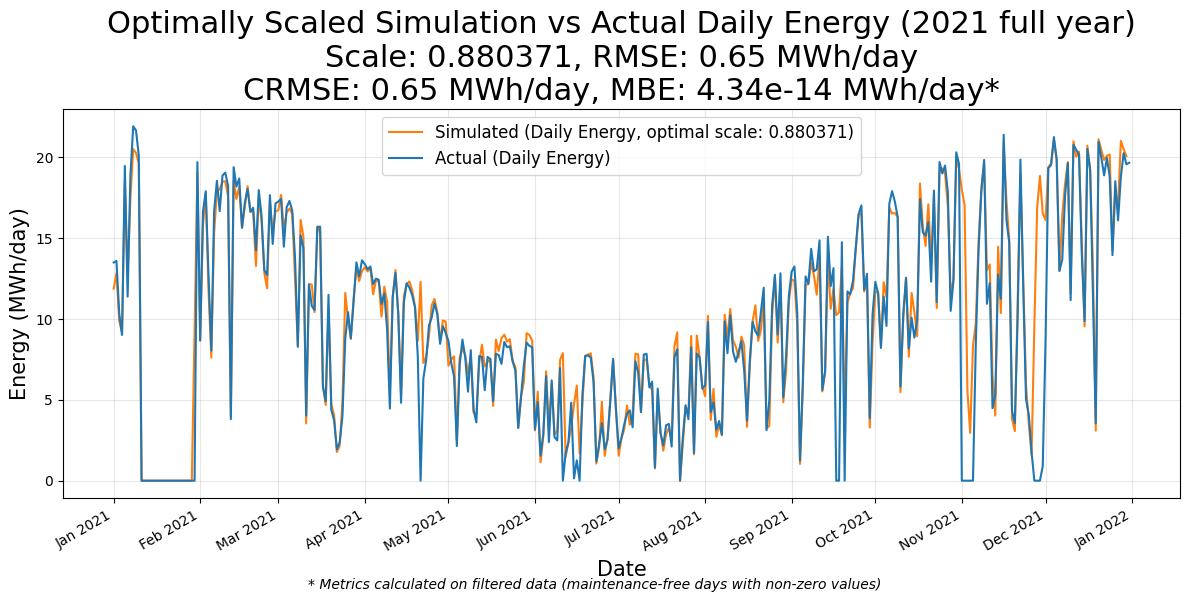


=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===
2021 simulation data points: 364
2021 actual data points: 365
Scaled Daily Energy Min: 0.00 MWh/day
Scaled Daily Energy Max: 21.12 MWh/day
Scaled Daily Energy Mean: 10.02 MWh/day
Actual Daily Energy Min: 0.00 MWh/day
Actual Daily Energy Max: 21.93 MWh/day
Actual Daily Energy Mean: 9.52 MWh/day


In [8]:
# Define options at the beginning
apply_clipping = True  # Set to False to disable clipping
clipping_threshold = 2.392 # MW - power clipping threshold 
target_mbe_tolerance = 1e-13  # Target absolute MBE to achieve

# First check if EArray needs conversion (avoid error if already numeric)
if pd.api.types.is_object_dtype(simulation_results_df['EArray']):
    # Only convert if it's still a string/object type
    simulation_results_df['EArray'] = pd.to_numeric(
        simulation_results_df['EArray'].str.replace(',', '.'), 
        errors='coerce'
    )
    print("Converted EArray column from string to numeric")
else:
    print("EArray column is already numeric type:", simulation_results_df['EArray'].dtype)

# Apply clipping to raw power values BEFORE energy conversion
if apply_clipping:
    original_max = simulation_results_df['EArray'].max()
    clipped_count = (simulation_results_df['EArray'] > clipping_threshold).sum()
    simulation_results_df['EArray'] = simulation_results_df['EArray'].clip(upper=clipping_threshold)
    print(f"Applied {clipping_threshold} MW clipping to power values: {clipped_count} values clipped")
    print(f"Maximum power reduced from {original_max:.2f} MW to {simulation_results_df['EArray'].max():.2f} MW")

# Now set the index and sort
if 'timestamp' in simulation_results_df.columns:
    simulation_results_df.set_index('timestamp', inplace=True)
    simulation_results_df.sort_index(inplace=True)
    print("Set timestamp as index")

# Convert Power (MW) to Energy (MWh) for 5-minute data by multiplying by time fraction
df['Energy_MWh'] = df[inverter] * (5/60)  # 5 minutes = 5/60 hours

# Resample actual power data to daily energy totals (MWh/day)
daily_actual_energy = df['Energy_MWh'].resample('D').sum()
print(f"Resampled actual power from {len(df)} 5-minute intervals to {len(daily_actual_energy)} daily totals")

# Convert hourly simulation data (MW) to hourly energy (MWh) and resample to daily
simulation_results_df['EArray_MWh'] = simulation_results_df['EArray'] * 1.0  # 1 hour energy
daily_simulated_energy = simulation_results_df['EArray_MWh'].resample('D').sum()
print(f"Resampled simulated power from {len(simulation_results_df)} hourly values to {len(daily_simulated_energy)} daily totals")

# ...existing code...

# Create a combined dataframe with both actual and simulated energy for metrics calculation
print("\n=== DATA FILTERING FOR METRICS CALCULATION ===")
print("Step 1: Creating filtered dataframe for metrics")
metrics_df = pd.DataFrame()
metrics_df['Actual'] = daily_actual_energy
metrics_df['Simulated'] = daily_simulated_energy

# Filter to include only timestamps where both actual and simulated energy exist
initial_rows = len(metrics_df)
metrics_df = metrics_df.dropna()
print(f"After filtering for matching dates: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} NaN values)")

# REMOVED: Filter to include only timestamps where both actual and simulated energy are non-zero
# The line below is removed to keep zero values in the dataset
# metrics_df = metrics_df[(metrics_df['Actual'] > 0) & (metrics_df['Simulated'] > 0)]
print("Zero filtering step removed - keeping all data points including zeros")

# Load the maintenance-free days from the text file
print("\nStep 2: Loading and applying maintenance-free days filter")
maintenance_free_days_file = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\remaining_dates_2021.txt"
try:
    with open(maintenance_free_days_file, 'r') as f:
        maintenance_free_days = [line.strip() for line in f.readlines() if line.strip()]
    
    print(f"Loaded {len(maintenance_free_days)} maintenance-free days")
    
    # Convert maintenance-free days to datetime for filtering
    maintenance_free_dates = pd.to_datetime(maintenance_free_days)
    
    # Filter the metrics dataframe to only include maintenance-free days
    metrics_df['date'] = metrics_df.index.date
    initial_rows = len(metrics_df)
    metrics_df = metrics_df[metrics_df['date'].isin([date.date() for date in maintenance_free_dates])]
    
    print(f"After filtering for maintenance-free days: {len(metrics_df)} data points (removed {initial_rows - len(metrics_df)} points)")
    
except Exception as e:
    print(f"Error loading maintenance-free days: {e}")
    print("Continuing with only the non-NaN data points")

# Print the date range of the filtered data
if len(metrics_df) > 0:
    print(f"\nFiltered data date range: {metrics_df.index.min()} to {metrics_df.index.max()}")
    print(f"Number of unique days in filtered data: {len(metrics_df['date'].unique())}")
else:
    print("\nWarning: No data points remain after filtering!")
    print("Please check your maintenance-free days file and data availability.")

# Check if we have enough data to proceed
if len(metrics_df) < 10:
    print("\nWARNING: Very few data points remain after filtering!")
    print("Results may not be statistically significant.")

# ...rest of the code remains the same...

# Function to calculate MBE for a given scale factor (uses filtered data)
def calculate_mbe(scale_factor, apply_clip=False, clip_threshold=2400):
    """Calculate Mean Bias Error for given scale factor"""
    # Scale the simulated data (clipping already applied at power level)
    scaled_data = metrics_df['Simulated'] * scale_factor
    
    # Calculate MBE
    return np.mean(scaled_data - metrics_df['Actual'])

print("\n=== SCALING FACTOR OPTIMIZATION ===")
print(f"Target MBE tolerance: {target_mbe_tolerance:.2e}")

# Binary search to find optimal scaling factor
def find_optimal_scaling_factor(min_factor=0.5, max_factor=2.0, max_iterations=100):
    print("\nStarting binary search for optimal scaling factor...")
    print(f"Initial search range: [{min_factor:.8f}, {max_factor:.8f}]")
    
    iterations = 0
    best_factor = None
    best_mbe = float('inf')
    
    while iterations < max_iterations:
        iterations += 1
        mid_factor = (min_factor + max_factor) / 2
        
        # Calculate MBE for the current factor
        mbe = calculate_mbe(mid_factor, apply_clipping, clipping_threshold)
        
        # Track the best factor found
        if abs(mbe) < abs(best_mbe):
            best_factor = mid_factor
            best_mbe = mbe
        
        print(f"Iteration {iterations}: Factor = {mid_factor:.10f}, MBE = {mbe:.10e}")
        
        # Check if we've reached the target precision
        if abs(mbe) < target_mbe_tolerance:
            print(f"✓ Converged! Found factor with MBE below tolerance.")
            return mid_factor, mbe, iterations
        
        # Adjust search range based on MBE sign
        if mbe > 0:  # MBE is positive, need to decrease factor
            max_factor = mid_factor
        else:  # MBE is negative, need to increase factor
            min_factor = mid_factor
        
        # Check if search range is too small (reached numerical precision limit)
        if max_factor - min_factor < 1e-15:
            print(f"! Reached numerical precision limit after {iterations} iterations.")
            print(f"  Best MBE achieved: {best_mbe:.12e}")
            return best_factor, best_mbe, iterations
    
    print(f"! Reached maximum iterations ({max_iterations}).")
    print(f"  Best MBE achieved: {best_mbe:.12e}")
    return best_factor, best_mbe, iterations

# Only proceed with optimization if we have data
if len(metrics_df) > 0:
    # Find the optimal scaling factor using filtered data
    optimal_factor, final_mbe, iterations = find_optimal_scaling_factor()

    print("\n=== OPTIMIZATION RESULTS ===")
    print(f"Optimal scaling factor: {optimal_factor:.10f}")
    print(f"Final MBE: {final_mbe:.12e} MWh/day")
    print(f"Found in {iterations} iterations")

    # Apply the optimal scaling factor to the filtered data for metrics
    PVsyst_scaling = optimal_factor
    print(f"\nApplying optimal scale factor {PVsyst_scaling:.10f} to PVsyst data...")

    # Apply scale factor to filtered data (clipping already applied at power level)
    metrics_df['Simulated_scaled'] = metrics_df['Simulated'] * PVsyst_scaling
    
    # No need to apply clipping again since it was done at the power level
    metrics_df['Simulated_display'] = metrics_df['Simulated_scaled']

    # Calculate error metrics with optimal scaling (using filtered data)
    # 1. RMSE (Root Mean Square Error)
    rmse = np.sqrt(mean_squared_error(metrics_df['Actual'], metrics_df['Simulated_display']))
    
    # 2. CRMSE (Centralized Root Mean Square Error)
    actual_centered = metrics_df['Actual'] - metrics_df['Actual'].mean()
    simulated_centered = metrics_df['Simulated_display'] - metrics_df['Simulated_display'].mean()
    crmse = np.sqrt(np.mean((actual_centered - simulated_centered)**2))
    
    # 3. MBE (Mean Bias Error) - should be very close to zero
    mbe = np.mean(metrics_df['Simulated_display'] - metrics_df['Actual'])
    
    print("\n=== ERROR METRICS WITH OPTIMAL SCALING (ON FILTERED DATA) ===")
    print(f"RMSE: {rmse:.4f} MWh/day")
    print(f"CRMSE: {crmse:.4f} MWh/day")
    print(f"MBE: {mbe:.12e} MWh/day")  # Using scientific notation for precision
    # calcualte the normalised RMSE as a percentage of the range of actual values
    nrmse = rmse / (metrics_df['Actual'].max() - metrics_df['Actual'].min())
    print(f"nRMSE: {nrmse:.4%} of actual range")
    
    # Verify if target was met
    if abs(mbe) < target_mbe_tolerance:
        print(f"✓ SUCCESS: |MBE| = {abs(mbe):.12e} < {target_mbe_tolerance:.2e}")
    else:
        print(f"! WARNING: |MBE| = {abs(mbe):.12e} > {target_mbe_tolerance:.2e}")
        print("  Target tolerance not achieved exactly due to numerical precision limits.")

    # Create a figure showing optimized results for 2021 data only
    plt.figure(figsize=long_hoz_figsize)

    # Convert hourly simulation data to daily for plotting (all data)
    all_daily_simulated = simulation_results_df['EArray_MWh'].resample('D').sum()
    
    # Apply the same scaling factor to all simulation data for plotting
    all_daily_simulated_scaled = all_daily_simulated * PVsyst_scaling
    
    # # Apply clipping if enabled
    # if apply_clipping:
    #     all_daily_simulated_display = all_daily_simulated_scaled.clip(upper=clipping_threshold)
    #     earray_label = f'Simulated (Daily Energy, optimal scale: {PVsyst_scaling:.6f}, clipped)'
    # else:
    all_daily_simulated_display = all_daily_simulated_scaled
    earray_label = f'Simulated (Daily Energy, optimal scale: {PVsyst_scaling:.6f})'
        
    # FILTER FOR 2021 DATA ONLY
    # Filter simulated and actual data to only include 2021
    year_2021_simulated = all_daily_simulated_display[all_daily_simulated_display.index.year == 2021]
    year_2021_actual = daily_actual_energy[daily_actual_energy.index.year == 2021]
    
    print(f"\n=== 2021 DATA FILTERING ===")
    print(f"Total days in 2021 with simulation data: {len(year_2021_simulated)}")
    print(f"Total days in 2021 with actual data: {len(year_2021_actual)}")

    # Plot 2021 scaled simulation data
    plt.plot(year_2021_simulated.index, year_2021_simulated, 
             linewidth=1.5, color='#ff7f0e', label=earray_label)

    # Plot 2021 actual energy data
    plt.plot(year_2021_actual.index, year_2021_actual, 
             linewidth=1.5, color='#1f77b4', label='Actual (Daily Energy)')

    # Add labels and title
    plt.xlabel('Date', fontsize=axis_label_size)
    plt.ylabel('Energy (MWh/day)', fontsize=axis_label_size)

    # Add metrics to title (but note these are from filtered data)
    plt.title(f'Optimally Scaled Simulation vs Actual Daily Energy (2021 full year)\n'
              f'Scale: {optimal_factor:.6f}, RMSE: {rmse:.2f} MWh/day\n'
              f'CRMSE: {crmse:.2f} MWh/day, MBE: {mbe:.2e} MWh/day*', 
              fontsize=title_size)
    
    # Add a note about metrics
    plt.figtext(0.5, 0.01, 
                '* Metrics calculated on filtered data (maintenance-free days with non-zero values)',
                ha='center', fontsize=10, style='italic')

    # Add legend and formatting
    plt.legend(fontsize=text_size)
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate()
    plt.tight_layout()

    # Show plot
    plt.show()

    # Print statistics for 2021 data
    print(f"\n=== STATISTICS WITH OPTIMAL SCALING (2021 DATA) ===")
    print(f"2021 simulation data points: {len(year_2021_simulated)}")
    print(f"2021 actual data points: {len(year_2021_actual)}")
    print(f"Scaled Daily Energy Min: {year_2021_simulated.min():.2f} MWh/day")
    print(f"Scaled Daily Energy Max: {year_2021_simulated.max():.2f} MWh/day")
    print(f"Scaled Daily Energy Mean: {year_2021_simulated.mean():.2f} MWh/day")
    print(f"Actual Daily Energy Min: {year_2021_actual.min():.2f} MWh/day")
    print(f"Actual Daily Energy Max: {year_2021_actual.max():.2f} MWh/day")
    print(f"Actual Daily Energy Mean: {year_2021_actual.mean():.2f} MWh/day")
else:
    print("\nERROR: No data points remain after filtering. Cannot proceed with optimization.")
    print("Please check your maintenance-free days file and data availability.")

#### 3.2.3.2. Plot the data after filtering


=== FILTERED 2021 DATA FOR PLOTTING ===
Total days in filtered 2021 data: 233
Mean difference: 4.344831599889282e-14
Median difference: 0.0
The difference is PVsyst - Measured


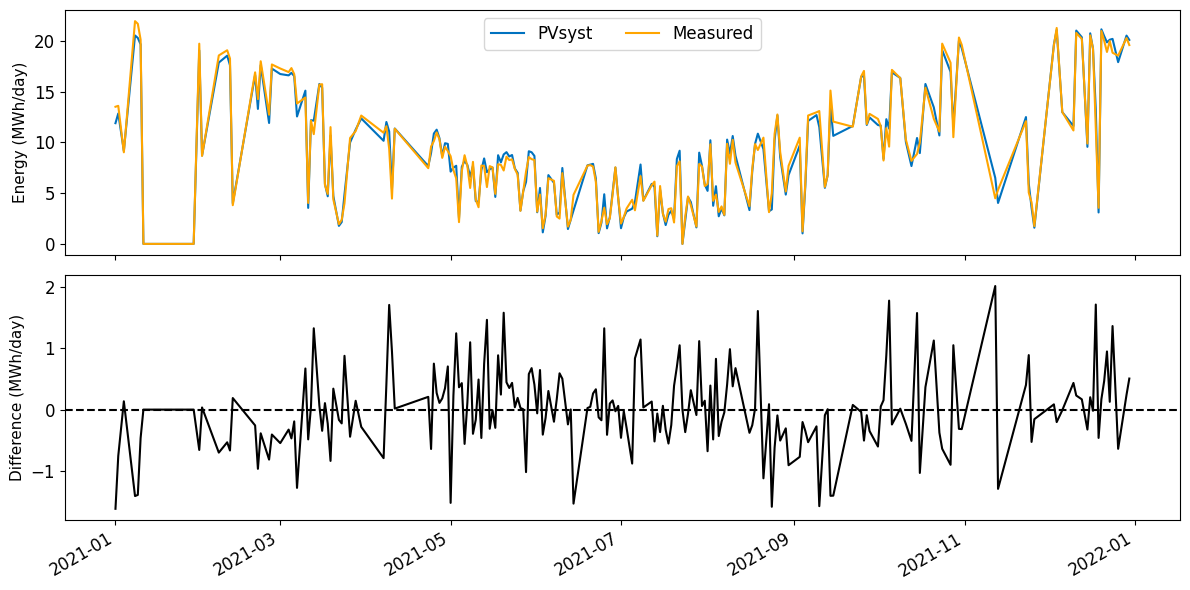


Evaluation Metrics:
MBE   : 0.000 MWh/day
MAE   : 0.469 MWh/day
RMSE  : 0.651 MWh/day
CRMSE : 0.651 MWh/day
CMAE  : 0.469 MWh/day
nRMSE : 2.971% (range)
NMAE  : 2.137% (range)
MAPE  : 7.381%

Seasonal Evaluation Metrics:

Autumn Metrics:
MBE  (Mean Bias Error): 0.143 MWh/day
RMSE (Root Mean Square Error): 0.661 MWh/day
CRMSE (Centered RMSE): 0.646 MWh/day
nRMSE (Normalized RMSE): 3.016%
NMAE (Normalized MAE): 2.336%
MAPE (Mean Absolute Percentage Error): 7.058%

Spring Metrics:
MBE  (Mean Bias Error): -0.108 MWh/day
RMSE (Root Mean Square Error): 0.825 MWh/day
CRMSE (Centered RMSE): 0.818 MWh/day
nRMSE (Normalized RMSE): 3.764%
NMAE (Normalized MAE): 2.864%
MAPE (Mean Absolute Percentage Error): 7.448%

Summer Metrics:
MBE  (Mean Bias Error): -0.103 MWh/day
RMSE (Root Mean Square Error): 0.578 MWh/day
CRMSE (Centered RMSE): 0.569 MWh/day
nRMSE (Normalized RMSE): 2.635%
NMAE (Normalized MAE): 1.633%
MAPE (Mean Absolute Percentage Error): 3.752%

Winter Metrics:
MBE  (Mean Bias Error): 

In [9]:
# Create a two-panel figure showing optimized results for filtered 2021 data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                              gridspec_kw={'height_ratios':[1,1]})

# Filter metrics_df to only include 2021 data - this ensures we use the same filtered data
# that was used for metrics calculation
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()
print(f"\n=== FILTERED 2021 DATA FOR PLOTTING ===")
print(f"Total days in filtered 2021 data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Plot only the filtered 2021 data with optimal scaling in top panel
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated_display'], 
             label='PVsyst', color='#0072BF')
    
    # Plot the same filtered 2021 actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals (Simulated - Actual)
    residuals = filtered_2021_metrics['Simulated_display'] - filtered_2021_metrics['Actual']
    print("Mean difference:", residuals.mean())
    print("Median difference:", residuals.median())
    print('The difference is PVsyst - Measured')
    
    # Plot residuals in bottom panel
    ax2.plot(residuals.index, residuals, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    # ax2.set_ylim(-100, 100)  # Same y-limits as example
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add x-axis formatting
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    
    # Show plot
    plt.show()
    
    # Calculate additional metrics like the example
    mbe = residuals.mean()
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    crmse = np.sqrt(np.mean((residuals - mbe)**2))
    cmae = np.mean(np.abs(residuals - mbe))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse = rmse / meas_range * 100
    nmae = mae / meas_range * 100
    mape = np.mean(np.abs(residuals / filtered_2021_metrics['Actual'])) * 100
    
    # Print metrics
    print("\nEvaluation Metrics:")
    print(f"MBE   : {mbe:.3f} MWh/day")
    print(f"MAE   : {mae:.3f} MWh/day")
    print(f"RMSE  : {rmse:.3f} MWh/day")
    print(f"CRMSE : {crmse:.3f} MWh/day")
    print(f"CMAE  : {cmae:.3f} MWh/day")
    print(f"nRMSE : {nrmse:.3f}% (range)")
    print(f"NMAE  : {nmae:.3f}% (range)")
    print(f"MAPE  : {mape:.3f}%")
    
    # Seasonal metrics calculation
    df_season = pd.DataFrame({
        'PVsyst': filtered_2021_metrics['Simulated_display'],
        'Measured': filtered_2021_metrics['Actual']
    })
    df_season['Residual'] = df_season['PVsyst'] - df_season['Measured']
    
    # Define a function to determine the season for a given date (southern hemisphere)
    def get_season(date):
        month = date.month
        if month in [12, 1, 2]:
            return 'Summer'
        elif month in [3, 4, 5]:
            return 'Autumn'
        elif month in [6, 7, 8]:
            return 'Winter'
        elif month in [9, 10, 11]:
            return 'Spring'
    
    # Create a new column with the season for each day
    df_season['Season'] = df_season.index.to_series().apply(get_season)
    
    # Compute and print evaluation metrics for each season
    print("\nSeasonal Evaluation Metrics:")
    for season, group in df_season.groupby('Season'):
        season_mbe = group['Residual'].mean()
        season_rmse = np.sqrt(np.mean(group['Residual']**2))
        season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
        season_nrmse = (season_rmse / meas_range) * 100
        season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
        season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
        print(f"\n{season} Metrics:")
        print("MBE  (Mean Bias Error): {:.3f} MWh/day".format(season_mbe))
        print("RMSE (Root Mean Square Error): {:.3f} MWh/day".format(season_rmse))
        print("CRMSE (Centered RMSE): {:.3f} MWh/day".format(season_crmse))
        print("nRMSE (Normalized RMSE): {:.3f}%".format(season_nrmse))
        print("NMAE (Normalized MAE): {:.3f}%".format(season_nmae))
        print("MAPE (Mean Absolute Percentage Error): {:.3f}%".format(season_mape))
    
    # Save the comparison plot to file
    # plot_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_vs_measured_comparison.png"
    # fig.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    # print(f"\nPlot saved to: {plot_file_path}")
    plt.show()
    
#     # Save the metrics to a text file
#     metrics_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_metrics.txt"
#     with open(metrics_file_path, 'w') as f:
#         f.write("EVALUATION METRICS\n")
#         f.write("=================\n\n")
#         f.write(f"Optimal scaling factor: {optimal_factor:.6f}\n")
#         f.write(f"Filtered data points: {len(filtered_2021_metrics)}\n\n")
#         f.write(f"MBE   : {mbe:.3f} MWh/day\n")
#         f.write(f"MAE   : {mae:.3f} MWh/day\n")
#         f.write(f"RMSE  : {rmse:.3f} MWh/day\n")
#         f.write(f"CRMSE : {crmse:.3f} MWh/day\n")
#         f.write(f"CMAE  : {cmae:.3f} MWh/day\n")
#         f.write(f"nRMSE : {nrmse:.3f}% (range)\n")
#         f.write(f"NMAE  : {nmae:.3f}% (range)\n")
#         f.write(f"MAPE  : {mape:.3f}%\n\n")
        
#         f.write("SEASONAL METRICS\n")
#         f.write("===============\n\n")
#         for season, group in df_season.groupby('Season'):
#             season_mbe = group['Residual'].mean()
#             season_rmse = np.sqrt(np.mean(group['Residual']**2))
#             season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
#             season_nrmse = (season_rmse / meas_range) * 100
#             season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
#             season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
#             f.write(f"{season} Metrics:\n")
#             f.write("MBE  (Mean Bias Error): {:.3f} MWh/day\n".format(season_mbe))
#             f.write("RMSE (Root Mean Square Error): {:.3f} MWh/day\n".format(season_rmse))
#             f.write("CRMSE (Centered RMSE): {:.3f} MWh/day\n".format(season_crmse))
#             f.write("nRMSE (Normalized RMSE): {:.3f}%\n".format(season_nrmse))
#             f.write("NMAE (Normalized MAE): {:.3f}%\n".format(season_nmae))
#             f.write("MAPE (Mean Absolute Percentage Error): {:.3f}%\n\n".format(season_mape))
    
#     print(f"Metrics saved to: {metrics_file_path}")
    
# else:
#     print("\nERROR: No filtered data points from 2021 remain after filtering.")
#     print("Please check your maintenance-free days file and data availability.")

### 3.2.4. Daily filtered without sclaing


=== FILTERED 2021 DATA FOR PLOTTING (UNSCALED) ===
Total days in filtered 2021 data: 233
Mean difference (unscaled): 1.155939699570816
Median difference (unscaled): 1.0766
The difference is PVsyst - Measured


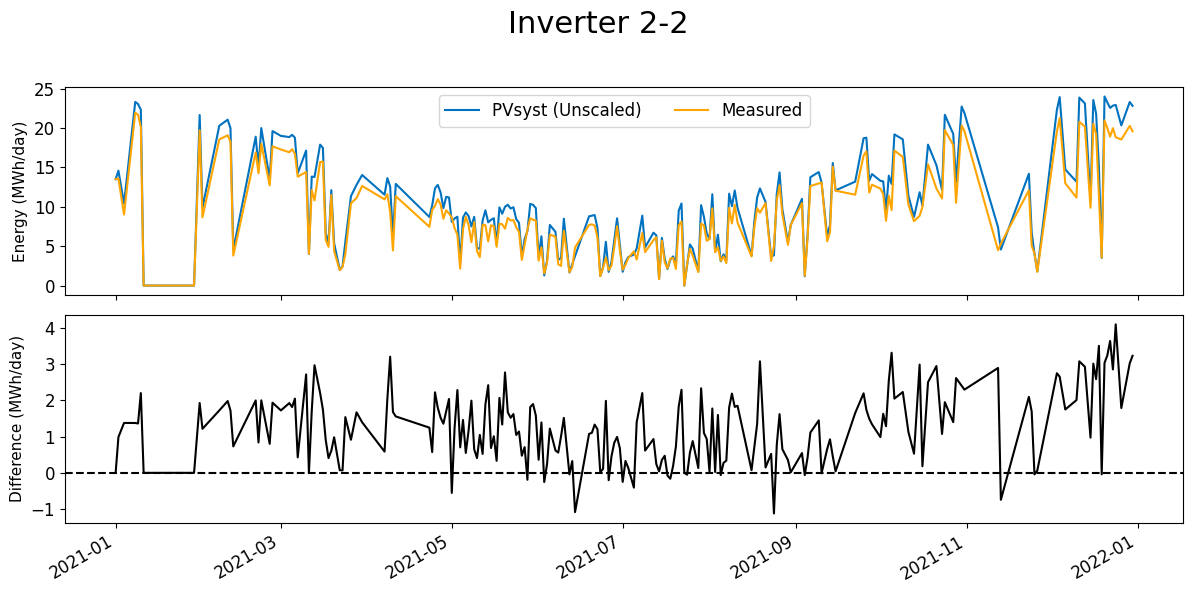


Evaluation Metrics for Inverter 2-2 (UNSCALED):
Optimal scaling factor (not applied): 0.880371
MBE   : 1.156 MWh/day
MAE   : 1.202 MWh/day
RMSE  : 1.537 MWh/day
CRMSE : 1.013 MWh/day
CMAE  : 0.851 MWh/day
nRMSE : 7.008% (range)
NMAE  : 5.482% (range)
MAPE  : 14.947%

Seasonal Evaluation Metrics (UNSCALED):

Autumn Metrics:
MBE  (Mean Bias Error): 1.335 MWh/day
RMSE (Root Mean Square Error): 1.548 MWh/day
CRMSE (Centered RMSE): 0.784 MWh/day
nRMSE (Normalized RMSE): 7.059%
NMAE (Normalized MAE): 6.193%
MAPE (Mean Absolute Percentage Error): 16.783%

Spring Metrics:
MBE  (Mean Bias Error): 1.402 MWh/day
RMSE (Root Mean Square Error): 1.723 MWh/day
CRMSE (Centered RMSE): 1.001 MWh/day
nRMSE (Normalized RMSE): 7.856%
NMAE (Normalized MAE): 6.589%
MAPE (Mean Absolute Percentage Error): 13.783%

Summer Metrics:
MBE  (Mean Bias Error): 1.353 MWh/day
RMSE (Root Mean Square Error): 1.859 MWh/day
CRMSE (Centered RMSE): 1.276 MWh/day
nRMSE (Normalized RMSE): 8.479%
NMAE (Normalized MAE): 6.176%


In [10]:
# %matplotlib inline

# Create a two-panel figure showing filtered 2021 data WITHOUT scaling
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=long_hoz_figsize, sharex=True,
                              gridspec_kw={'height_ratios':[1,1]})

# Add a proper title at the top of the figure with inverter information
fig.suptitle(f'Inverter {inverter}', 
             fontsize=title_size, y=0.98)

# Filter metrics_df to only include 2021 data - this ensures we use the same filtered data
# that was used for metrics calculation
filtered_2021_metrics = metrics_df[metrics_df.index.year == 2021].copy()
print(f"\n=== FILTERED 2021 DATA FOR PLOTTING (UNSCALED) ===")
print(f"Total days in filtered 2021 data: {len(filtered_2021_metrics)}")

if len(filtered_2021_metrics) > 0:
    # Plot the unscaled simulated data (but still filtered)
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Simulated'], 
             label='PVsyst (Unscaled)', color='#0072BF')
    
    # Plot the filtered actual data
    ax1.plot(filtered_2021_metrics.index, filtered_2021_metrics['Actual'], 
             label='Measured', color='orange')
    
    # Add labels and formatting for top panel
    ax1.set_ylabel('Energy (MWh/day)', fontsize=axis_label_size-4)
    ax1.legend(fontsize=text_size, loc='upper center', ncol=2)
    ax1.tick_params(labelsize=axis_num_size)
    
    # Calculate residuals WITHOUT scaling (Simulated - Actual)
    residuals_unscaled = filtered_2021_metrics['Simulated'] - filtered_2021_metrics['Actual']
    print("Mean difference (unscaled):", residuals_unscaled.mean())
    print("Median difference (unscaled):", residuals_unscaled.median())
    print('The difference is PVsyst - Measured')
    
    # Plot unscaled residuals in bottom panel
    ax2.plot(residuals_unscaled.index, residuals_unscaled, color='black', label='Difference')
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_ylabel('Difference (MWh/day)', fontsize=axis_label_size-4)
    # ax2.set_ylim(-100, 100)  # Same y-limits as example
    ax2.tick_params(labelsize=axis_num_size)
    
    # Add x-axis formatting
    plt.gcf().autofmt_xdate()
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate the suptitle
    
    # Show plot
    plt.show()
    
    # Calculate metrics on UNSCALED data
    mbe_unscaled = residuals_unscaled.mean()
    mae_unscaled = np.mean(np.abs(residuals_unscaled))
    rmse_unscaled = np.sqrt(np.mean(residuals_unscaled**2))
    crmse_unscaled = np.sqrt(np.mean((residuals_unscaled - mbe_unscaled)**2))
    cmae_unscaled = np.mean(np.abs(residuals_unscaled - mbe_unscaled))
    
    meas_range = filtered_2021_metrics['Actual'].max() - filtered_2021_metrics['Actual'].min()
    nrmse_unscaled = rmse_unscaled / meas_range * 100
    nmae_unscaled = mae_unscaled / meas_range * 100
    mape_unscaled = np.mean(np.abs(residuals_unscaled / filtered_2021_metrics['Actual'])) * 100
    
    # Print metrics for unscaled data including the scaling factor information
    print(f"\nEvaluation Metrics for Inverter {inverter} (UNSCALED):")
    print(f"Optimal scaling factor (not applied): {optimal_factor:.6f}")
    print(f"MBE   : {mbe_unscaled:.3f} MWh/day")
    print(f"MAE   : {mae_unscaled:.3f} MWh/day")
    print(f"RMSE  : {rmse_unscaled:.3f} MWh/day")
    print(f"CRMSE : {crmse_unscaled:.3f} MWh/day")
    print(f"CMAE  : {cmae_unscaled:.3f} MWh/day")
    print(f"nRMSE : {nrmse_unscaled:.3f}% (range)")
    print(f"NMAE  : {nmae_unscaled:.3f}% (range)")
    print(f"MAPE  : {mape_unscaled:.3f}%")
    
    # Rest of the code remains the same...
    
    # Seasonal metrics calculation for unscaled data
    df_season_unscaled = pd.DataFrame({
        'PVsyst': filtered_2021_metrics['Simulated'],
        'Measured': filtered_2021_metrics['Actual']
    })
    df_season_unscaled['Residual'] = df_season_unscaled['PVsyst'] - df_season_unscaled['Measured']
    
    # Define a function to determine the season for a given date (southern hemisphere)
    def get_season(date):
        month = date.month
        if month in [12, 1, 2]:
            return 'Summer'
        elif month in [3, 4, 5]:
            return 'Autumn'
        elif month in [6, 7, 8]:
            return 'Winter'
        elif month in [9, 10, 11]:
            return 'Spring'
    
    # Create a new column with the season for each day
    df_season_unscaled['Season'] = df_season_unscaled.index.to_series().apply(get_season)
    
    # Compute and print evaluation metrics for each season (unscaled)
    print("\nSeasonal Evaluation Metrics (UNSCALED):")
    for season, group in df_season_unscaled.groupby('Season'):
        season_mbe = group['Residual'].mean()
        season_rmse = np.sqrt(np.mean(group['Residual']**2))
        season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
        season_nrmse = (season_rmse / meas_range) * 100
        season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
        season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
        print(f"\n{season} Metrics:")
        print("MBE  (Mean Bias Error): {:.3f} MWh/day".format(season_mbe))
        print("RMSE (Root Mean Square Error): {:.3f} MWh/day".format(season_rmse))
        print("CRMSE (Centered RMSE): {:.3f} MWh/day".format(season_crmse))
        print("nRMSE (Normalized RMSE): {:.3f}%".format(season_nrmse))
        print("NMAE (Normalized MAE): {:.3f}%".format(season_nmae))
        print("MAPE (Mean Absolute Percentage Error): {:.3f}%".format(season_mape))
    
    # Save the comparison plot to file
    plot_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_vs_measured_comparison_unscaled.png"
    fig.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    print(f"\nUnscaled plot saved to: {plot_file_path}")
    
    # Save the metrics to a text file
    metrics_file_path = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_metrics_unscaled.txt"
    with open(metrics_file_path, 'w') as f:
        f.write("EVALUATION METRICS (UNSCALED)\n")
        f.write("=================\n\n")
        f.write(f"Note: No scaling applied (raw simulation results)\n")
        f.write(f"Filtered data points: {len(filtered_2021_metrics)}\n\n")
        f.write(f"MBE   : {mbe_unscaled:.3f} MWh/day\n")
        f.write(f"MAE   : {mae_unscaled:.3f} MWh/day\n")
        f.write(f"RMSE  : {rmse_unscaled:.3f} MWh/day\n")
        f.write(f"CRMSE : {crmse_unscaled:.3f} MWh/day\n")
        f.write(f"CMAE  : {cmae_unscaled:.3f} MWh/day\n")
        f.write(f"nRMSE : {nrmse_unscaled:.3f}% (range)\n")
        f.write(f"NMAE  : {nmae_unscaled:.3f}% (range)\n")
        f.write(f"MAPE  : {mape_unscaled:.3f}%\n\n")
        
        f.write("SEASONAL METRICS (UNSCALED)\n")
        f.write("===============\n\n")
        for season, group in df_season_unscaled.groupby('Season'):
            season_mbe = group['Residual'].mean()
            season_rmse = np.sqrt(np.mean(group['Residual']**2))
            season_crmse = np.sqrt(np.mean((group['Residual'] - season_mbe)**2))
            season_nrmse = (season_rmse / meas_range) * 100
            season_nmae = (np.mean(np.abs(group['Residual'])) / meas_range) * 100
            season_mape = np.mean(np.abs(group['Residual'] / group['Measured'])) * 100
            f.write(f"{season} Metrics:\n")
            f.write("MBE  (Mean Bias Error): {:.3f} MWh/day\n".format(season_mbe))
            f.write("RMSE (Root Mean Square Error): {:.3f} MWh/day\n".format(season_rmse))
            f.write("CRMSE (Centered RMSE): {:.3f} MWh/day\n".format(season_crmse))
            f.write("nRMSE (Normalized RMSE): {:.3f}%\n".format(season_nrmse))
            f.write("NMAE (Normalized MAE): {:.3f}%\n".format(season_nmae))
            f.write("MAPE (Mean Absolute Percentage Error): {:.3f}%\n\n".format(season_mape))
    
    print(f"Unscaled metrics saved to: {metrics_file_path}")
    
    # Display comparison between scaled and unscaled metrics
    print("\n=== COMPARISON: SCALED vs UNSCALED METRICS ===")
    print(f"Optimal scaling factor: {optimal_factor:.6f} (not applied in unscaled results)")
    print(f"MBE   : {mbe_unscaled:.3f} MWh/day (unscaled) vs {mbe:.3f} MWh/day (scaled)")
    print(f"RMSE  : {rmse_unscaled:.3f} MWh/day (unscaled) vs {rmse:.3f} MWh/day (scaled)")
    print(f"CRMSE : {crmse_unscaled:.3f} MWh/day (unscaled) vs {crmse:.3f} MWh/day (scaled)")
    
else:
    print("\nERROR: No filtered data points from 2021 remain after filtering.")
    print("Please check your maintenance-free days file and data availability.")

# 4. Param optimisation

## 4.1. Uc and Uv color map

### 4.1.1. Hay model

File exists: True
Data shape: (21, 9)
First few rows:
                                      file directory inverter_id model_name  \
0  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2        Hay   
1  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2        Hay   
2  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2        Hay   

   Uc   Uv      RMSE           MBE     CRMSE  The optimised scale factor  
0  10  0.0  0.676441 -6.731954e-14  0.676441                    1.028827  
1  11  0.0  1.137687 -7.532363e-14  1.137687                    1.130028  
2  12  0.0  0.864314  9.450905e-14  0.864314                    1.088012  
Minimum RMSE: 0.6573 at Uc = 21, Uv = 0.0


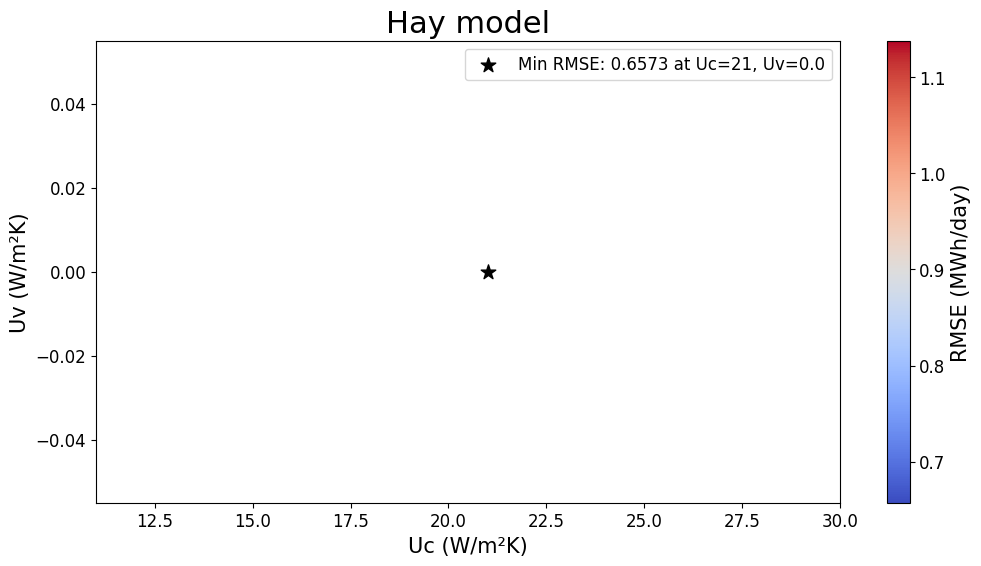

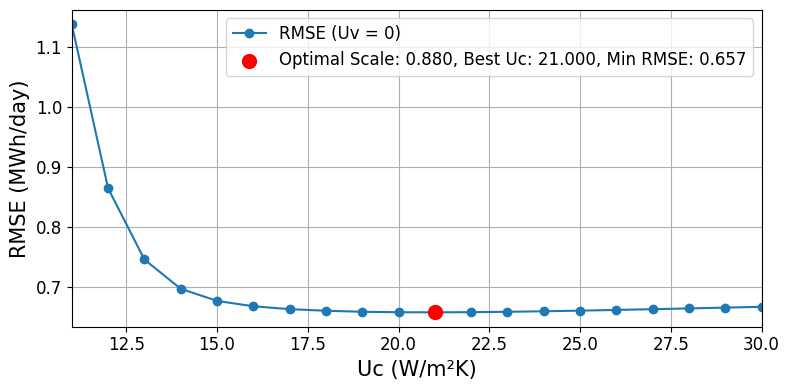

In [11]:
# define the sweeping results for visualisaing
UcUv_sweep_results = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_batch_evaluation_results_2_2_Hay.csv"

# Verify file exists
import os
print(f"File exists: {os.path.exists(UcUv_sweep_results)}")

# read the CSV file instead of Excel
sweep_df = pd.read_csv(UcUv_sweep_results)

# Print data shape and first few rows for debugging
print(f"Data shape: {sweep_df.shape}")
print("First few rows:")
print(sweep_df.head(3))

# Pivot the dataframe to create a grid for heatmap
pivot = sweep_df.pivot(index='Uv', columns='Uc', values='RMSE')
Uc_vals = pivot.columns.values
Uv_vals = pivot.index.values
RMSE_grid = pivot.values

plt.figure(figsize=long_hoz_figsize)
c = plt.pcolormesh(Uc_vals, Uv_vals, RMSE_grid, cmap='coolwarm', shading='auto')
cb = plt.colorbar(c, label='RMSE (MWh/day)')
cb.ax.tick_params(labelsize=axis_num_size)
cb.set_label('RMSE (MWh/day)', fontsize=axis_label_size)

plt.xlabel('Uc (W/m²K)', fontsize=axis_label_size)
plt.ylabel('Uv (W/m²K)', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.title("Hay model", fontsize=title_size)
plt.grid(False)

# Find the minimum RMSE and its indices
min_idx = np.unravel_index(np.nanargmin(RMSE_grid), RMSE_grid.shape)
min_Uc = Uc_vals[min_idx[1]]
min_Uv = Uv_vals[min_idx[0]]
min_RMSE = RMSE_grid[min_idx]

# Highlight the minimum RMSE pixel
plt.scatter(min_Uc, min_Uv, color='black', s=120, marker='*', label=f'Min RMSE: {min_RMSE:.4f} at Uc={min_Uc}, Uv={min_Uv}')
plt.legend(loc='best', fontsize=text_size)

# Print the Uc and Uv values for the minimum RMSE
print(f"Minimum RMSE: {min_RMSE:.4f} at Uc = {min_Uc}, Uv = {min_Uv}")

# set x limit
plt.xlim(11, 30)

plt.show()

# --- Plot Uc vs RMSE for Uv = 0 ---
if 0 in Uv_vals:
    idx_uv0 = np.where(Uv_vals == 0)[0][0]
    rmse_uv0 = RMSE_grid[idx_uv0, :]
    
    # Find minimum RMSE for Uv=0 case
    min_idx_uv0 = np.nanargmin(rmse_uv0)
    min_uc_uv0 = Uc_vals[min_idx_uv0]
    min_rmse_uv0 = rmse_uv0[min_idx_uv0]
    
    plt.figure(figsize=(8, 4))
    # Plot data with label for legend
    plt.plot(Uc_vals, rmse_uv0, marker='o', label=f'RMSE (Uv = 0)')
    
    # Plot minimum point with label for legend containing key information
    plt.scatter(min_uc_uv0, min_rmse_uv0, color='red', s=100, zorder=5,
               label=f'Optimal Scale: {PVsyst_scaling:.3f}, Best Uc: {min_uc_uv0:.3f}, Min RMSE: {min_rmse_uv0:.3f}')
    
    plt.xlabel('Uc (W/m²K)', fontsize=axis_label_size)
    plt.ylabel('RMSE (MWh/day)', fontsize=axis_label_size)
    
    # No title - removed as requested
    
    plt.grid(True)
    plt.xlim(11, 30)
    plt.xticks(fontsize=axis_num_size)
    plt.yticks(fontsize=axis_num_size)
    
    # Update annotation to use 3 decimal places
    # plt.annotate(f'Min RMSE: {min_rmse_uv0:.3f}\nat Uc = {min_uc_uv0:.3f}',
    #             xy=(min_uc_uv0, min_rmse_uv0),
    #             xytext=(min_uc_uv0+2, min_rmse_uv0),
    #             fontsize=text_size,
    #             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    
    # Add legend with all the information
    plt.legend(loc='best', fontsize=text_size)
    
    plt.tight_layout()
    plt.show()
else:
    print("Uv=0 is not present in the data, so Uc vs RMSE for Uv=0 cannot be plotted.")

### 4.1.2. Perez model

File exists: True
Data shape: (21, 9)
First few rows:
                                      file directory inverter_id model_name  \
0  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2      Perez   
1  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2      Perez   
2  C:\Users\z5183876\OneDrive - UNSW\Documents\Gi...         2-2      Perez   

   Uc   Uv      RMSE           MBE     CRMSE  The optimised scale factor  
0  10  0.0  0.675975 -5.970427e-14  0.675975                    1.015908  
1  11  0.0  1.189931  1.554503e-14  1.189931                    1.118892  
2  12  0.0  0.892312  9.043029e-14  0.892312                    1.075964  
Minimum RMSE: 0.6484 at Uc = 22, Uv = 0.0


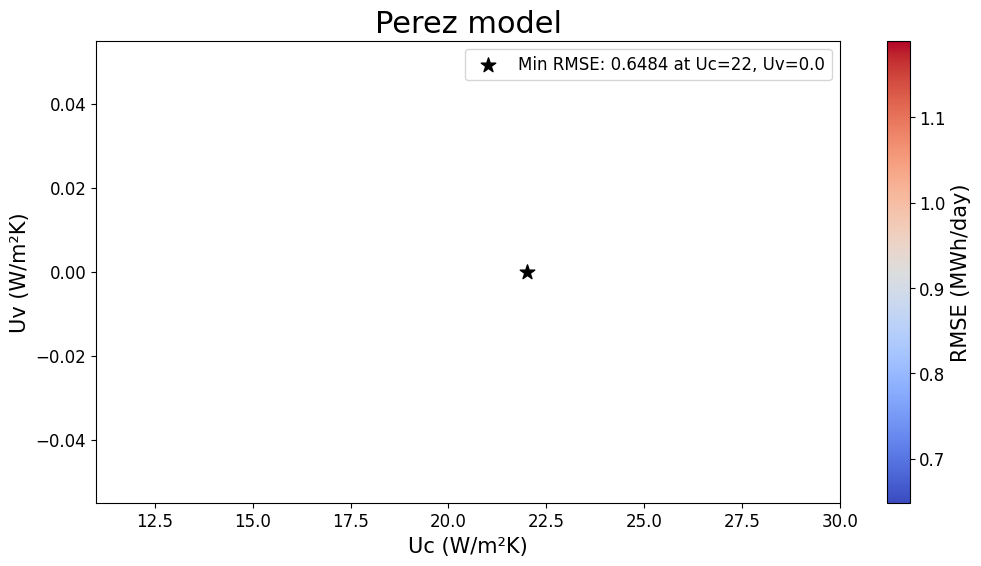

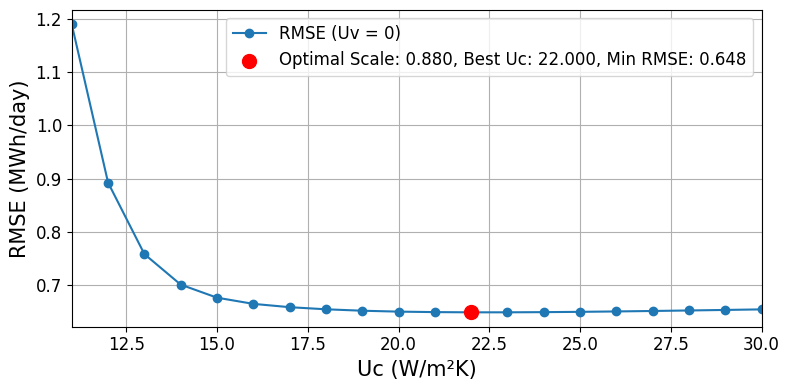

In [12]:
# define the sweeping results for visualisaing
UcUv_sweep_results = r"C:\Users\z5183876\OneDrive - UNSW\Documents\GitHub\25_09_02_Bomen_bifacial_gain_2021\Results\pvsyst_batch_evaluation_results_2_2_Perez.csv"
# Verify file exists
import os
print(f"File exists: {os.path.exists(UcUv_sweep_results)}")

# read the CSV file instead of Excel
sweep_df = pd.read_csv(UcUv_sweep_results)

# Print data shape and first few rows for debugging
print(f"Data shape: {sweep_df.shape}")
print("First few rows:")
print(sweep_df.head(3))

# Pivot the dataframe to create a grid for heatmap
pivot = sweep_df.pivot(index='Uv', columns='Uc', values='RMSE')
Uc_vals = pivot.columns.values
Uv_vals = pivot.index.values
RMSE_grid = pivot.values

plt.figure(figsize=long_hoz_figsize)
c = plt.pcolormesh(Uc_vals, Uv_vals, RMSE_grid, cmap='coolwarm', shading='auto')
cb = plt.colorbar(c, label='RMSE (MWh/day)')
cb.ax.tick_params(labelsize=axis_num_size)
cb.set_label('RMSE (MWh/day)', fontsize=axis_label_size)

plt.xlabel('Uc (W/m²K)', fontsize=axis_label_size)
plt.ylabel('Uv (W/m²K)', fontsize=axis_label_size)
plt.xticks(fontsize=axis_num_size)
plt.yticks(fontsize=axis_num_size)
plt.title("Perez model", fontsize=title_size)
plt.grid(False)

# Find the minimum RMSE and its indices
min_idx = np.unravel_index(np.nanargmin(RMSE_grid), RMSE_grid.shape)
min_Uc = Uc_vals[min_idx[1]]
min_Uv = Uv_vals[min_idx[0]]
min_RMSE = RMSE_grid[min_idx]

# Highlight the minimum RMSE pixel
plt.scatter(min_Uc, min_Uv, color='black', s=120, marker='*', label=f'Min RMSE: {min_RMSE:.4f} at Uc={min_Uc}, Uv={min_Uv}')
plt.legend(loc='best', fontsize=text_size)

# Print the Uc and Uv values for the minimum RMSE
print(f"Minimum RMSE: {min_RMSE:.4f} at Uc = {min_Uc}, Uv = {min_Uv}")

# set an x limit
plt.xlim(11, 30)

plt.show()

# --- Plot Uc vs RMSE for Uv = 0 ---
if 0 in Uv_vals:
    idx_uv0 = np.where(Uv_vals == 0)[0][0]
    rmse_uv0 = RMSE_grid[idx_uv0, :]
    
    # Find minimum RMSE for Uv=0 case
    min_idx_uv0 = np.nanargmin(rmse_uv0)
    min_uc_uv0 = Uc_vals[min_idx_uv0]
    min_rmse_uv0 = rmse_uv0[min_idx_uv0]
    
    plt.figure(figsize=(8, 4))
    # Plot data with label for legend
    plt.plot(Uc_vals, rmse_uv0, marker='o', label=f'RMSE (Uv = 0)')
    
    # Plot minimum point with label for legend containing key information
    plt.scatter(min_uc_uv0, min_rmse_uv0, color='red', s=100, zorder=5,
               label=f'Optimal Scale: {PVsyst_scaling:.3f}, Best Uc: {min_uc_uv0:.3f}, Min RMSE: {min_rmse_uv0:.3f}')
    
    plt.xlabel('Uc (W/m²K)', fontsize=axis_label_size)
    plt.ylabel('RMSE (MWh/day)', fontsize=axis_label_size)
    
    # No title - removed as requested
    
    plt.grid(True)
    plt.xlim(11, 30)
    plt.xticks(fontsize=axis_num_size)
    plt.yticks(fontsize=axis_num_size)
    
    # Update annotation to use 3 decimal places
    # plt.annotate(f'Min RMSE: {min_rmse_uv0:.3f}\nat Uc = {min_uc_uv0:.3f}',
    #             xy=(min_uc_uv0, min_rmse_uv0),
    #             xytext=(min_uc_uv0+2, min_rmse_uv0),
    #             fontsize=text_size,
    #             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))
    
    # Add legend with all the information
    plt.legend(loc='best', fontsize=text_size)
    
    plt.tight_layout()
    plt.show()
else:
    print("Uv=0 is not present in the data, so Uc vs RMSE for Uv=0 cannot be plotted.")